# IMDb Data Analysis with PySpark

This notebook allows you to interactively run IMDb data analyses using Apache Spark.


## 1. Initialize Spark Session


In [3]:
from pyspark.sql import SparkSession
from utils.reader import read_data

# Create Spark session
spark = SparkSession.builder \
    .appName("IMDBAnalysis-Jupyter") \
    .getOrCreate()

print("Spark session created successfully!")
print(f"Spark version: {spark.version}")


ModuleNotFoundError: No module named 'pyspark'

## 2. Load Data


In [2]:
# Load all dataframes
print("Loading IMDb datasets...")
dataframes = read_data(spark)
print("\nDatasets loaded:")
for name, df in dataframes.items():
    print(f"  - {name}: {df.count():,} rows")


Loading IMDb datasets...

Datasets loaded:


  - name.basics: 14,853,898 rows


  - title.akas: 53,865,751 rows


  - title.basics: 12,043,480 rows


  - title.crew: 12,043,480 rows


  - title.episode: 9,280,667 rows


  - title.principals: 95,660,392 rows
  - title.ratings: 1,634,159 rows


## 3. Import Analysis Functions


In [3]:
# Import all analysis functions
from analysis.actor_analysis import (
    actors_demography_stats,
    avg_rating_by_actor,
    young_actors_2000s,
    rising_stars,
    fading_stars
)

from analysis.tv_analysis import (
    correlation_seasons_rating,
    top_episodes_by_votes_and_rating,
    genre_seasons_influence,
    avg_rating_long_series,
    season_rating_diff,
    hook_shows,
    sophomore_slump
)

from analysis.genre_analysis import (
    genre_popularity_trend,
    genre_actor_cyclicality,
    genre_duration_rating_analysis,
    genre_evolution_analysis,
    genre_combinations_analysis,
    underrated_genre_combos
)

from analysis.director_analysis import (
    directors_increasing_ratings_trend,
    top_directors_by_high_rating_and_votes,
    director_career_span_analysis
)

from analysis.collaboration_analysis import (
    writer_director_collaboration,
    actor_director_collaboration
)

from analysis.localization_analysis import localization_gaps

print("All analysis functions imported successfully!")


All analysis functions imported successfully!


---
# Actor Analysis


### Actors Demography Stats


Analyzing actor demographics for regions: ['DE', 'FR', 'JP', 'IN', 'ES']


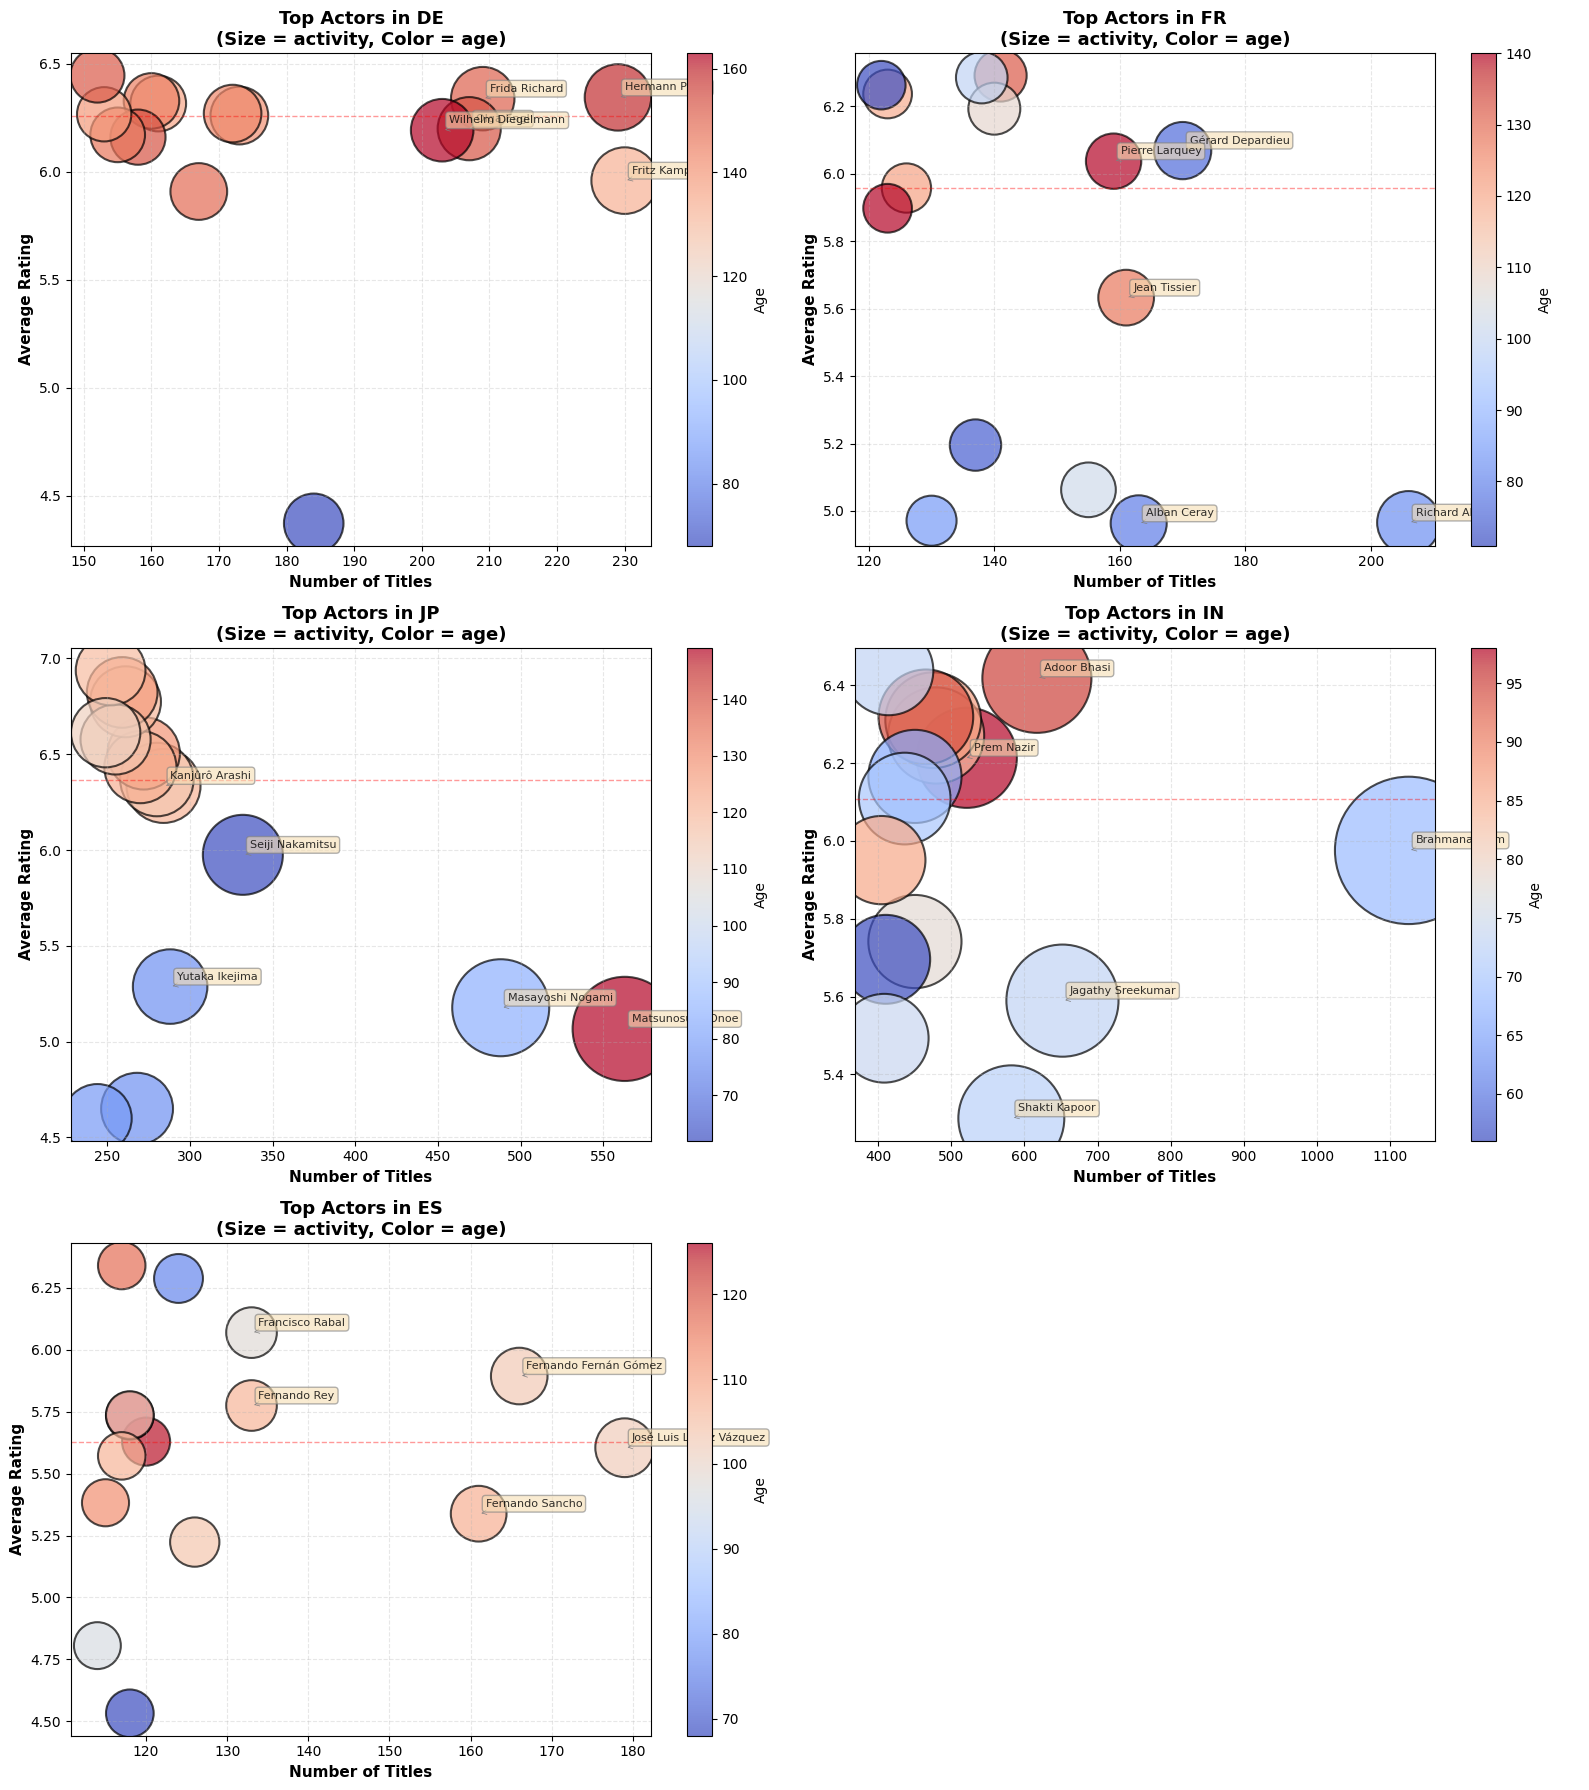

+------+--------------------+----------+-----------------+---+----+
|region|         primaryName|num_titles|       avg_rating|age|rank|
+------+--------------------+----------+-----------------+---+----+
|    DE|       Fritz Kampers|       230|5.959493679336354|133|   1|
|    DE|       Hermann Picha|       229|6.344827569764236|159|   2|
|    DE|       Frida Richard|       209|6.339024383847306|151|   3|
|    DE|           Olga Engl|       207|6.199999976158142|153|   4|
|    DE|  Wilhelm Diegelmann|       203|6.192857146263123|163|   5|
|    DE|        Eric Roberts|       184|4.372375692451857| 68|   6|
|    DE|        Theodor Loos|       173|6.260810802111754|141|   7|
|    DE|    Margarete Kupfer|       172|6.269999997615814|143|   8|
|    DE|   Erich Kaiser-Titz|       167|5.909090865742076|149|   9|
|    DE|     Georg Alexander|       161|6.316363646767356|136|  10|
|    DE|  Julius Falkenstein|       160|6.328571391957147|145|  11|
|    DE|Eduard von Winter...|       158|6.160714

In [4]:
result = actors_demography_stats(dataframes, save_path="./output")
result.show()


### Average Rating by Actor



BUSINESS QUESTION: Actors with highest average film rating (min. 10 films)


Filtering by top 5 regions: DE, FR, JP, IN, ES

Top-20 actors with highest average rating:


+-----------------------+----------+----------+-----------+---------+
|primaryName            |film_count|avg_rating|total_votes|birthYear|
+-----------------------+----------+----------+-----------+---------+
|Babymetal              |12        |9.21      |198        |NULL     |
|Moa Kikuchi            |14        |8.91      |1997       |NULL     |
|Suzuka Nakamoto        |14        |8.91      |1997       |1997     |
|Nagappa                |17        |8.85      |545        |NULL     |
|Kuppuraj               |14        |8.84      |331        |NULL     |
|Ramachandra Sastry H.R.|49        |8.69      |3659       |NULL     |
|Rajkumar               |237       |8.68      |15176      |1928     |
|Ganapathi Bhat         |40        |8.62      |1079       |NULL     |
|R.T. Rama              |14        |8.58      |381        |NULL     |
|Reeva Rachh            |10        |8.54      |7325       |NULL     |
|Papamma                |43        |8.51      |2311       |1926     |
|Raghavendra Rao    

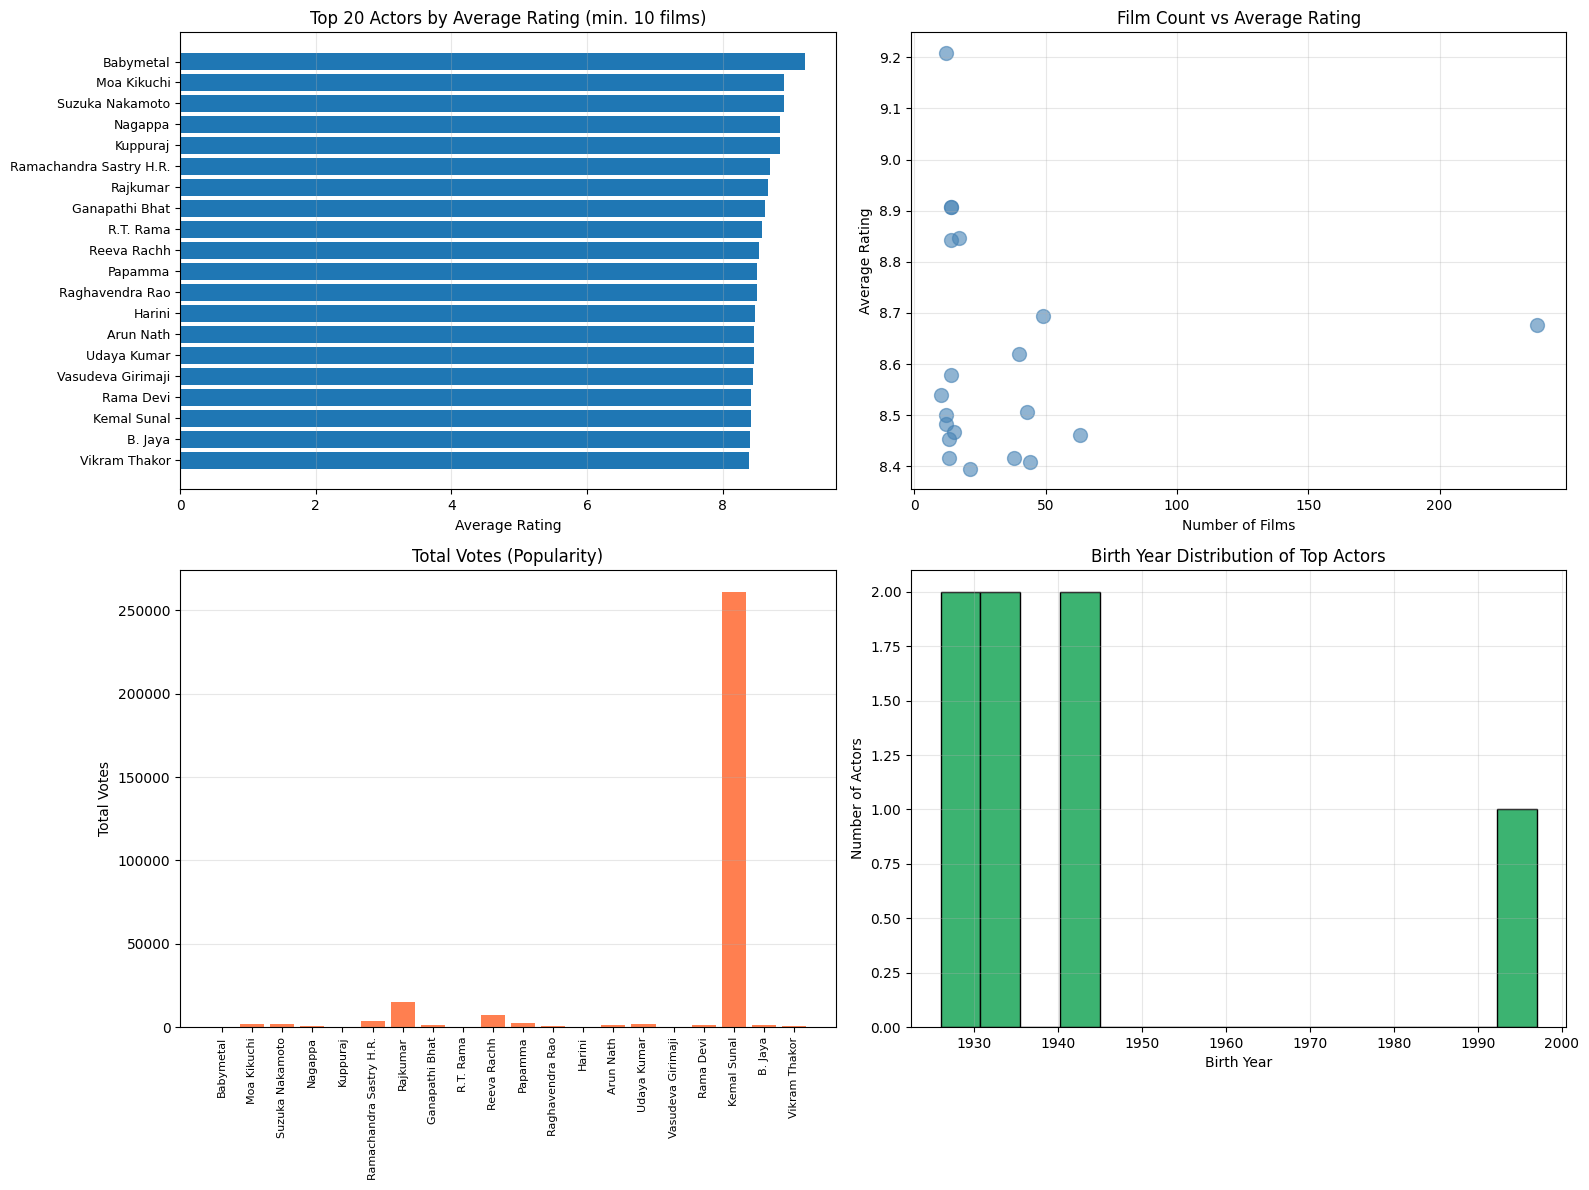

+---------+------------------+----------+-----------+-----------------+---------+
|   nconst|        avg_rating|film_count|total_votes|      primaryName|birthYear|
+---------+------------------+----------+-----------+-----------------+---------+
|nm0000012| 6.830000013775296|        90|     642396|      Bette Davis|     1908|
|nm0000021| 6.391489373876693|        47|     327336|    Joan Fontaine|     1917|
|nm0000023| 6.880000019073487|        30|     683571|     Judy Garland|     1922|
|nm0000029| 4.358333269755046|        12|      11183|Margaux Hemingway|     1954|
|nm0000086|6.1219511933443025|        82|     245734|   Louis de Funès|     1914|
|nm0000100|6.5083333651224775|        12|    2320202|   Rowan Atkinson|     1955|
|nm0000113| 6.046808516725581|        47|    6817071|   Sandra Bullock|     1964|
|nm0000131|  6.07916666732894|        72|    3966025|      John Cusack|     1966|
|nm0000141| 5.975757569977731|        33|    1141069|   David Duchovny|     1960|
|nm0000161| 5.91

In [28]:
result = avg_rating_by_actor(dataframes, save_path="./output")
result.show()


### Young Actors in 2000s



BUSINESS QUESTION: Actor age distribution in films 2020-2025


Filtering by top 5 regions: DE, FR, JP, IN, ES

Actor distribution by age groups in films 2020-2025:


+-------------------+-------------+-----------+-------+
|age_group          |unique_actors|total_roles|avg_age|
+-------------------+-------------+-----------+-------+
|18-25 (Youth)      |3595         |7033       |22.5   |
|26-35 (Prime)      |10454        |24392      |30.9   |
|36-45 (Mature)     |10994        |25954      |40.4   |
|46-55 (Experienced)|9113         |22424      |50.3   |
|56+ (Veterans)     |11139        |28425      |66.0   |
+-------------------+-------------+-----------+-------+


Trend by years (average actor age):


+---------+-------+-------------+
|startYear|avg_age|unique_actors|
+---------+-------+-------------+
|     2020|   44.6|        11245|
|     2021|   44.9|        12434|
|     2022|   45.4|        14221|
|     2023|   46.2|        14376|
|     2024|   46.8|        13503|
|     2025|   47.3|        10696|
+---------+-------+-------------+



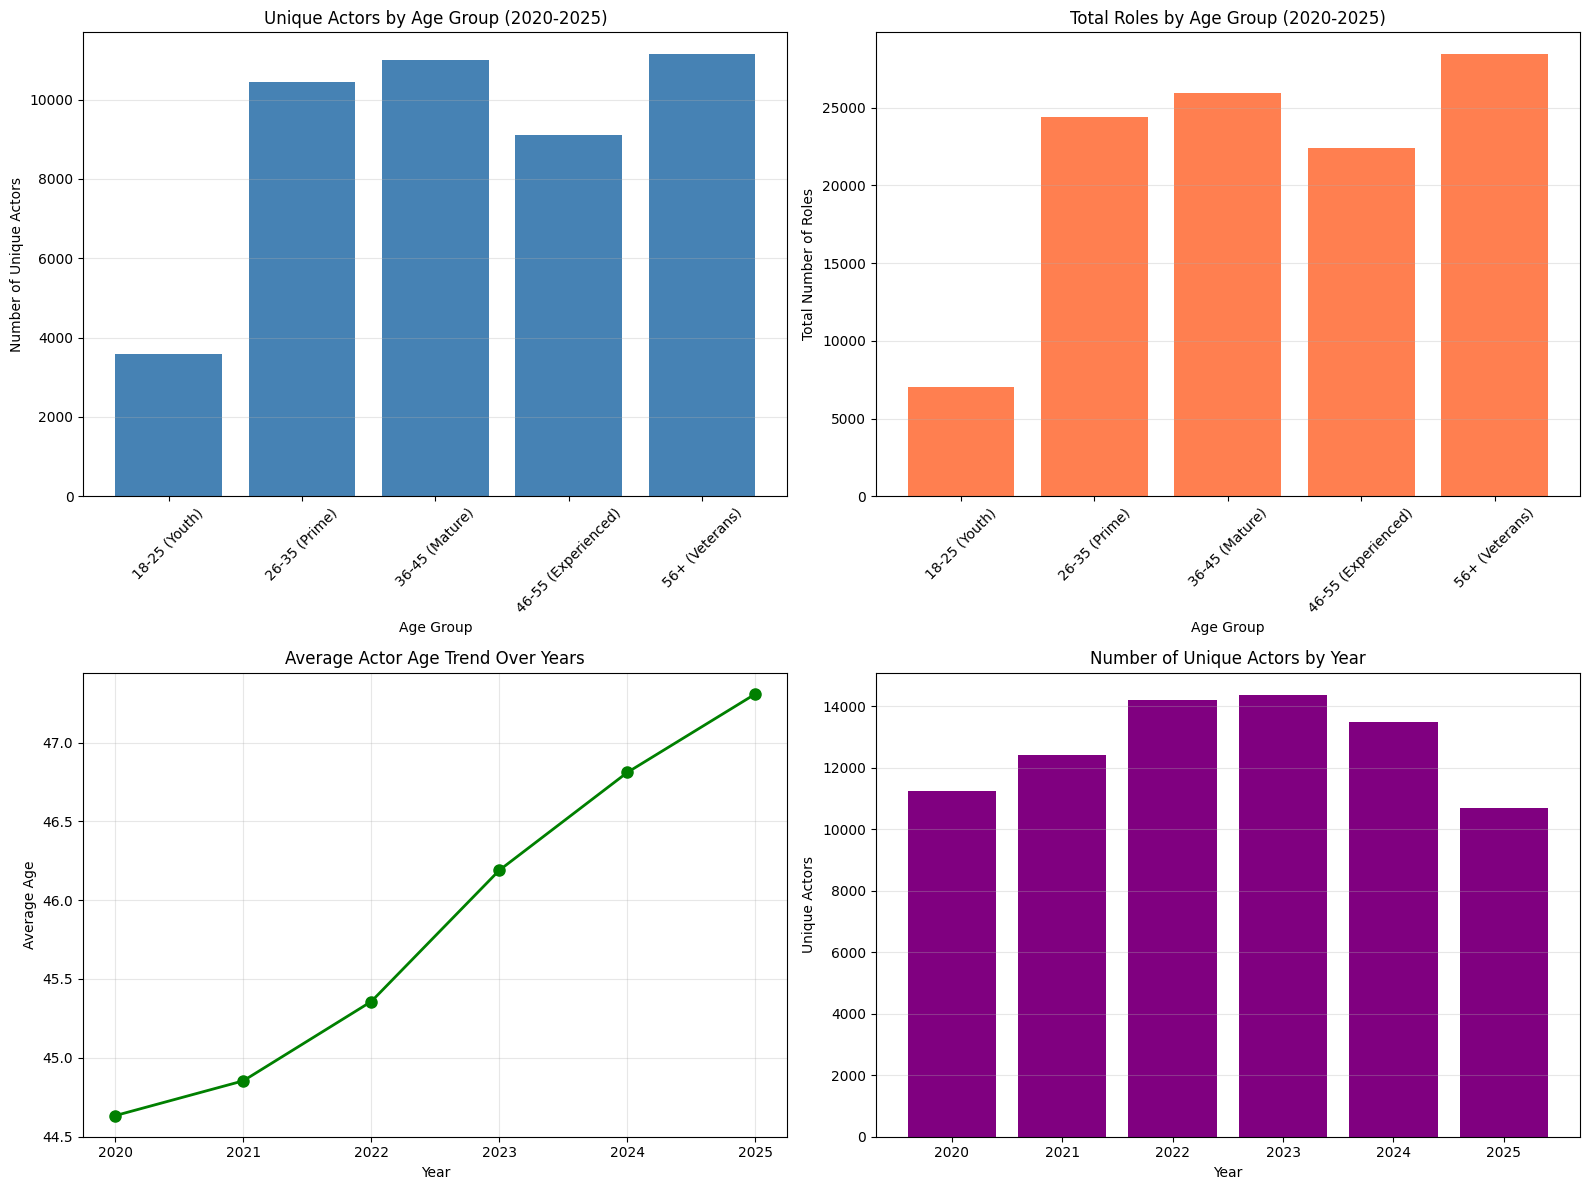

+-------------------+-------------+-----------+------------------+
|          age_group|unique_actors|total_roles|           avg_age|
+-------------------+-------------+-----------+------------------+
|      18-25 (Youth)|         3595|       7033|22.548698990473483|
|      26-35 (Prime)|        10454|      24392|30.918866841587406|
|     36-45 (Mature)|        10994|      25954| 40.43611774678277|
|46-55 (Experienced)|         9113|      22424| 50.28478415982875|
|     56+ (Veterans)|        11139|      28425| 65.97678100263852|
+-------------------+-------------+-----------+------------------+



In [6]:
result = young_actors_2000s(dataframes, save_path="./output")
result.show()


### Rising Stars


Analyzing rising stars for regions: ['DE', 'FR', 'JP', 'IN', 'ES']


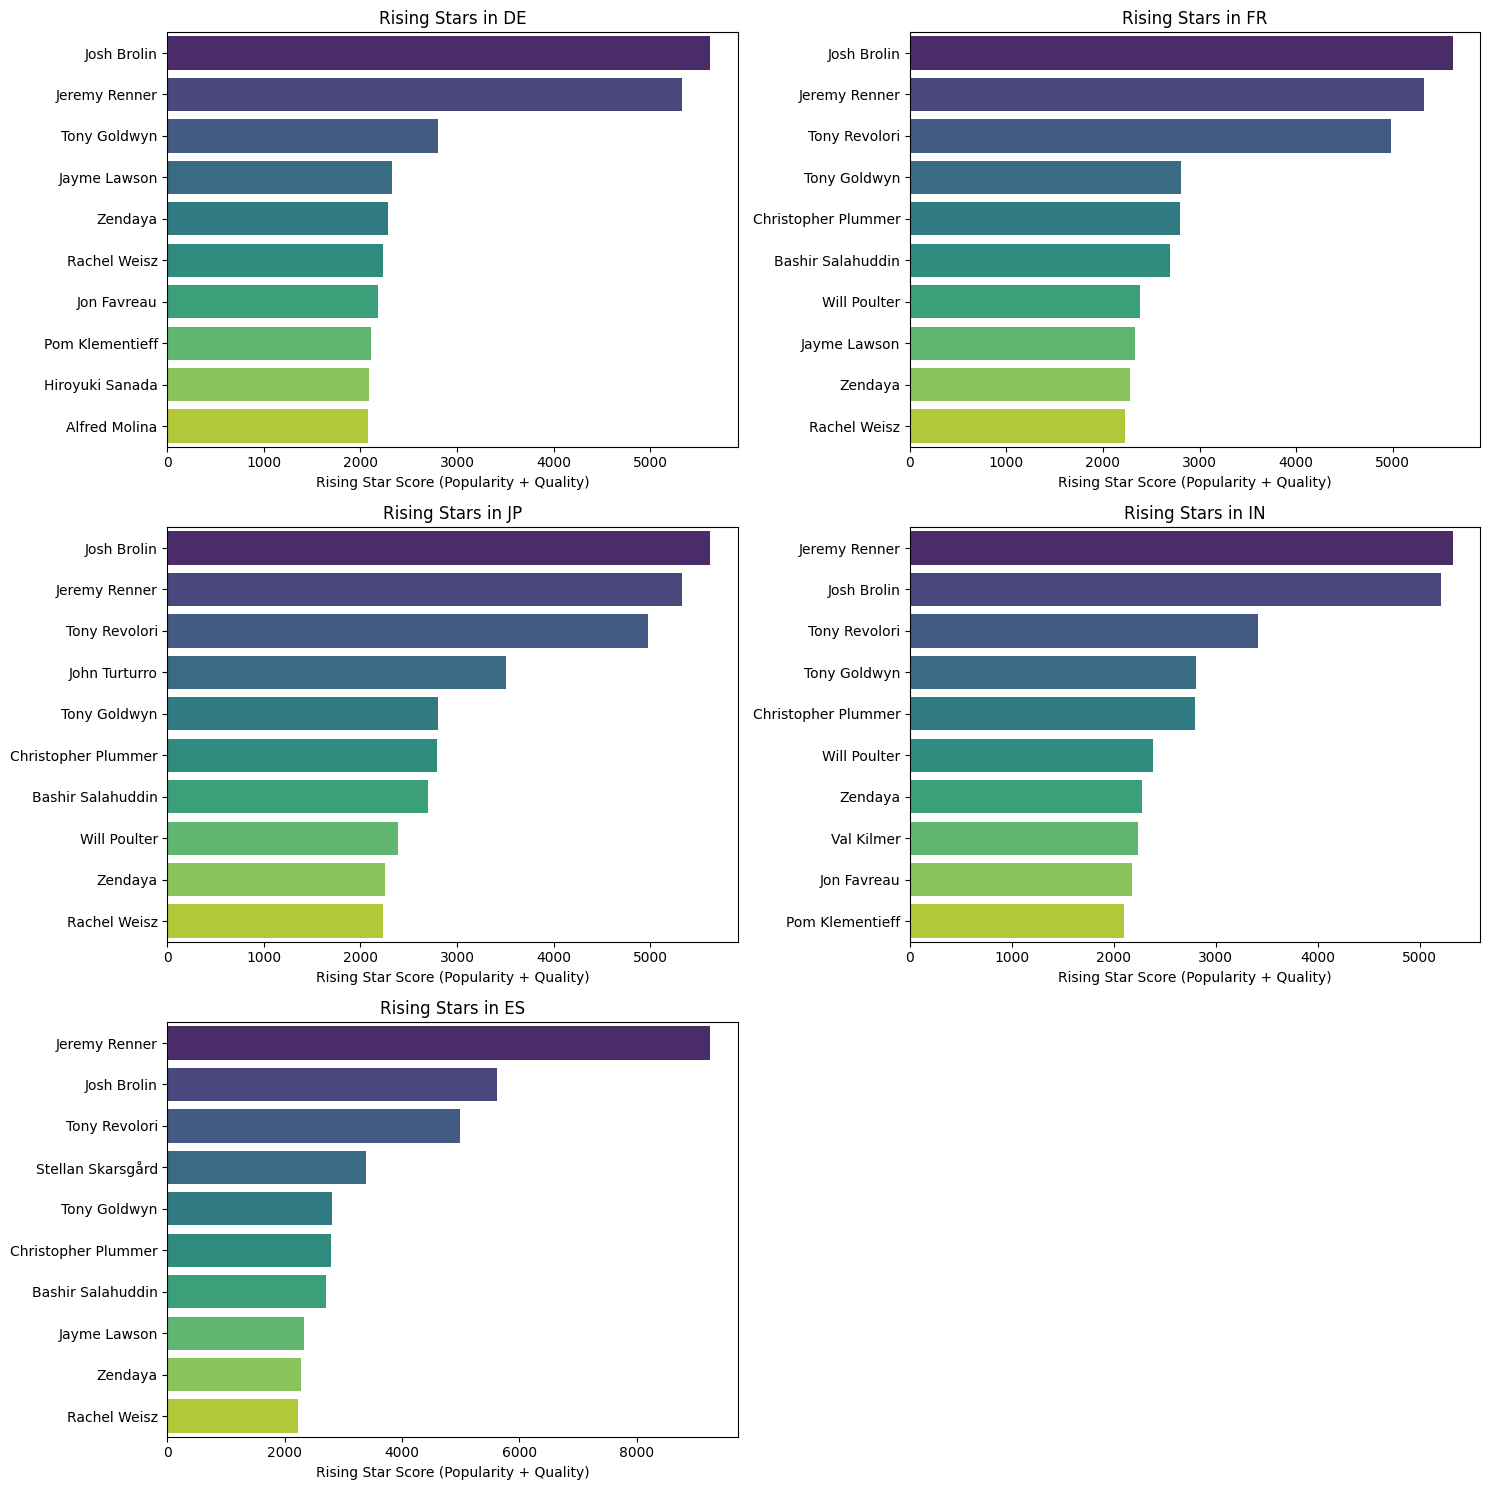

+------+-------------------+------------------+-----------------+--------------------+------------------+----+
|region|        primaryName| rising_star_score|avg_vote_velocity|    avg_rating_trend|overall_avg_rating|rank|
+------+-------------------+------------------+-----------------+--------------------+------------------+----+
|    DE|        Josh Brolin| 5625.191633652269|        756052.75|  1.1500000953674316| 7.424999952316284|   1|
|    DE|      Jeremy Renner| 5326.935333802382|774699.3333333334|  0.7333331108093262| 6.866666555404663|   2|
|    DE|       Tony Goldwyn|2807.6239439302685|         376996.5|-0.09999990463256836| 7.450000047683716|   3|
|    DE|       Jayme Lawson| 2327.880887008799|329770.3333333333|  0.3000000317891436| 7.050000111262003|   4|
|    DE|            Zendaya| 2281.478617482748|323385.5833333333|  0.6999999284744263| 7.033333381017049|   5|
|    DE|       Rachel Weisz| 2232.348808088541|         334659.0|-0.15000009536743164| 6.674999952316284|   6|
|

In [7]:
result = rising_stars(dataframes, save_path="./output")
result.show()


### Fading Stars


Analyzing fading stars for regions: ['DE', 'FR', 'JP', 'IN', 'ES']


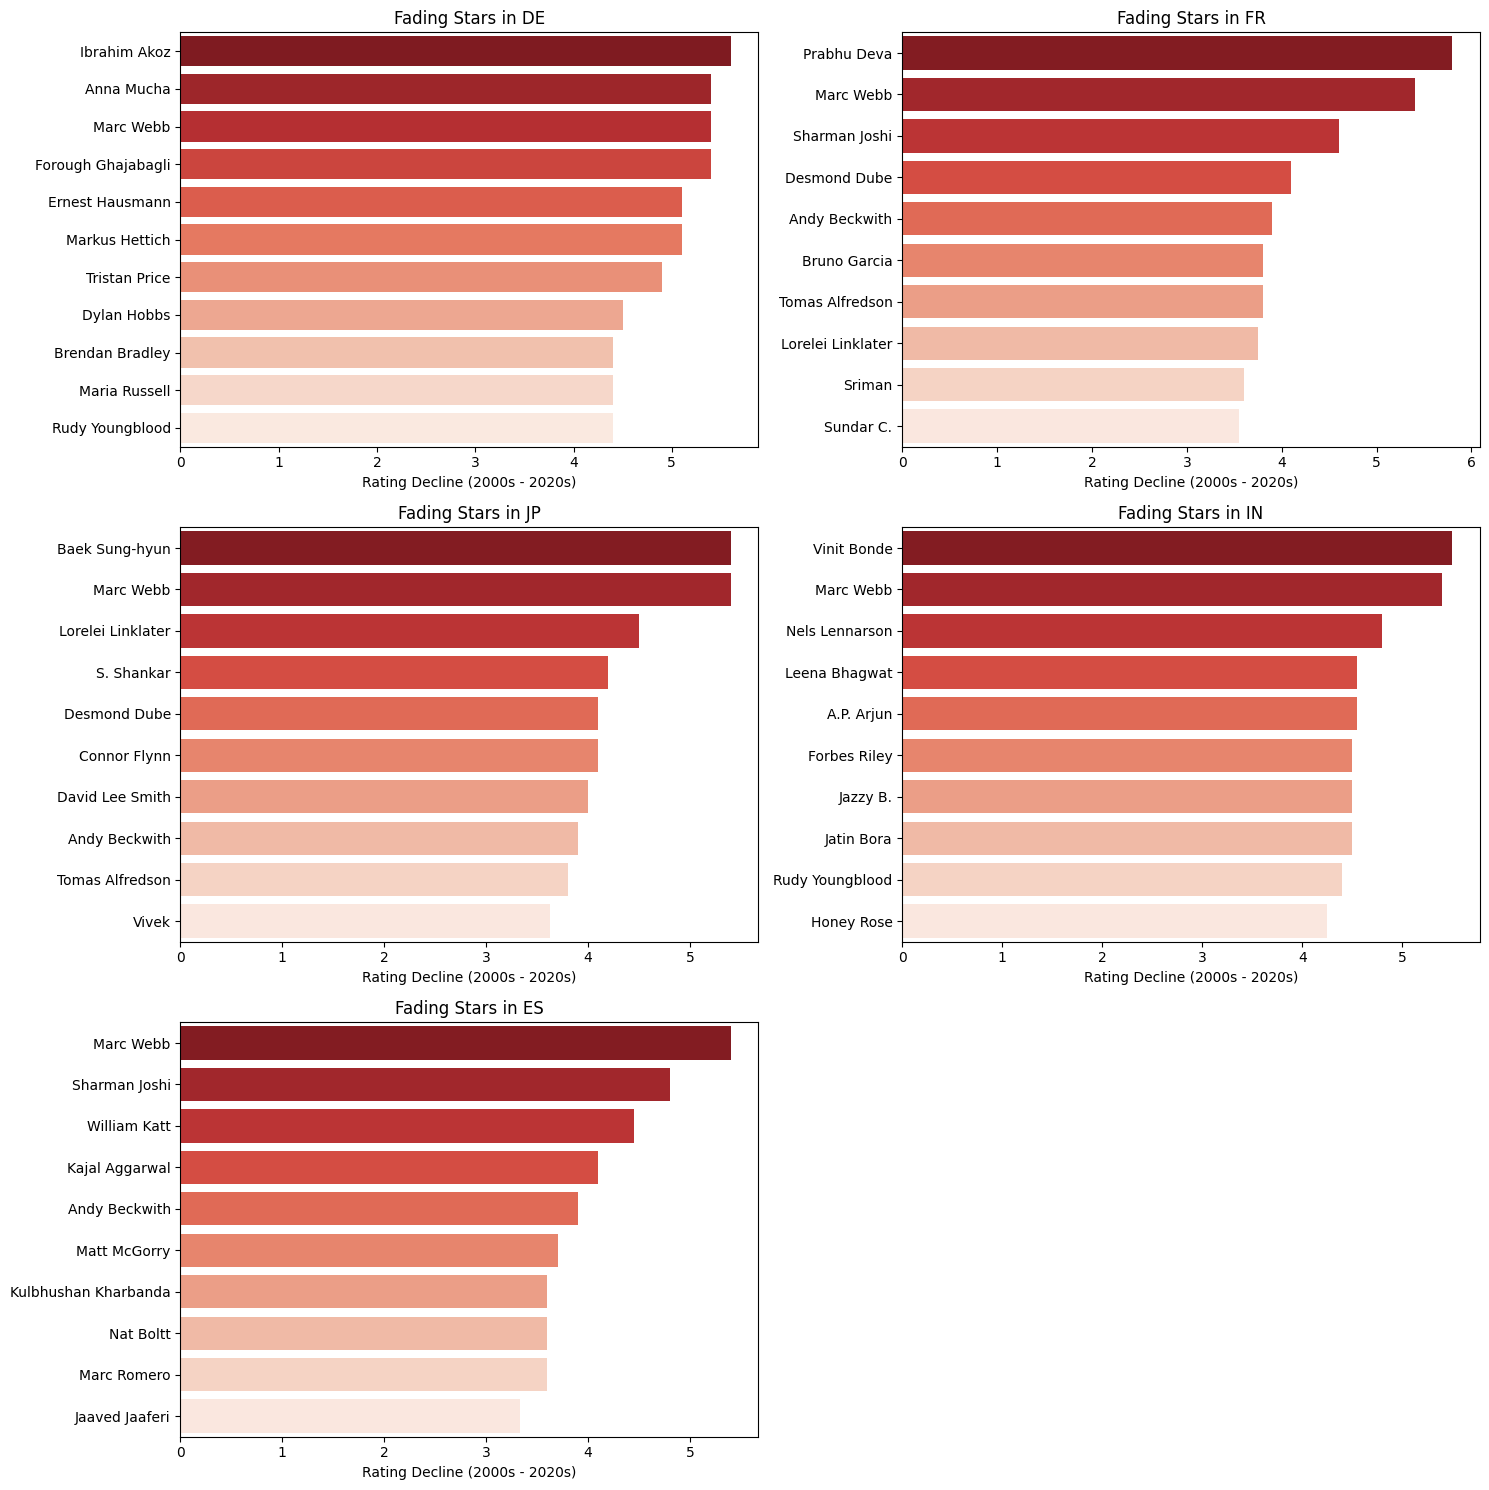

+------+--------------------+--------+-----------------+------------------+------------------+----+
|region|         primaryName|category|             2000|              2020|     decline_score|rank|
+------+--------------------+--------+-----------------+------------------+------------------+----+
|    DE|        Ibrahim Akoz|   actor|              8.0|2.4000000953674316| 5.599999904632568|   1|
|    DE|          Anna Mucha| actress|7.599999904632568|2.1999999284744263| 5.399999976158142|   2|
|    DE|           Marc Webb|director|7.599999904632568| 2.200000047683716|5.3999998569488525|   3|
|    DE|  Forough Ghajabagli| actress|7.599999904632568| 2.200000047683716|5.3999998569488525|   3|
|    DE|     Ernest Hausmann|   actor|7.599999904632568|               2.5| 5.099999904632568|   5|
|    DE|      Markus Hettich|   actor|8.399999618530273| 3.299999952316284| 5.099999666213989|   6|
|    DE|       Tristan Price|director|7.900000095367432|               3.0| 4.900000095367432|   7|


In [5]:
result = fading_stars(dataframes, save_path="./output")
result.show()


---
# TV Series Analysis


### Correlation Between Seasons and Rating


Filtering by top 5 regions: DE, FR, JP, IN, ES


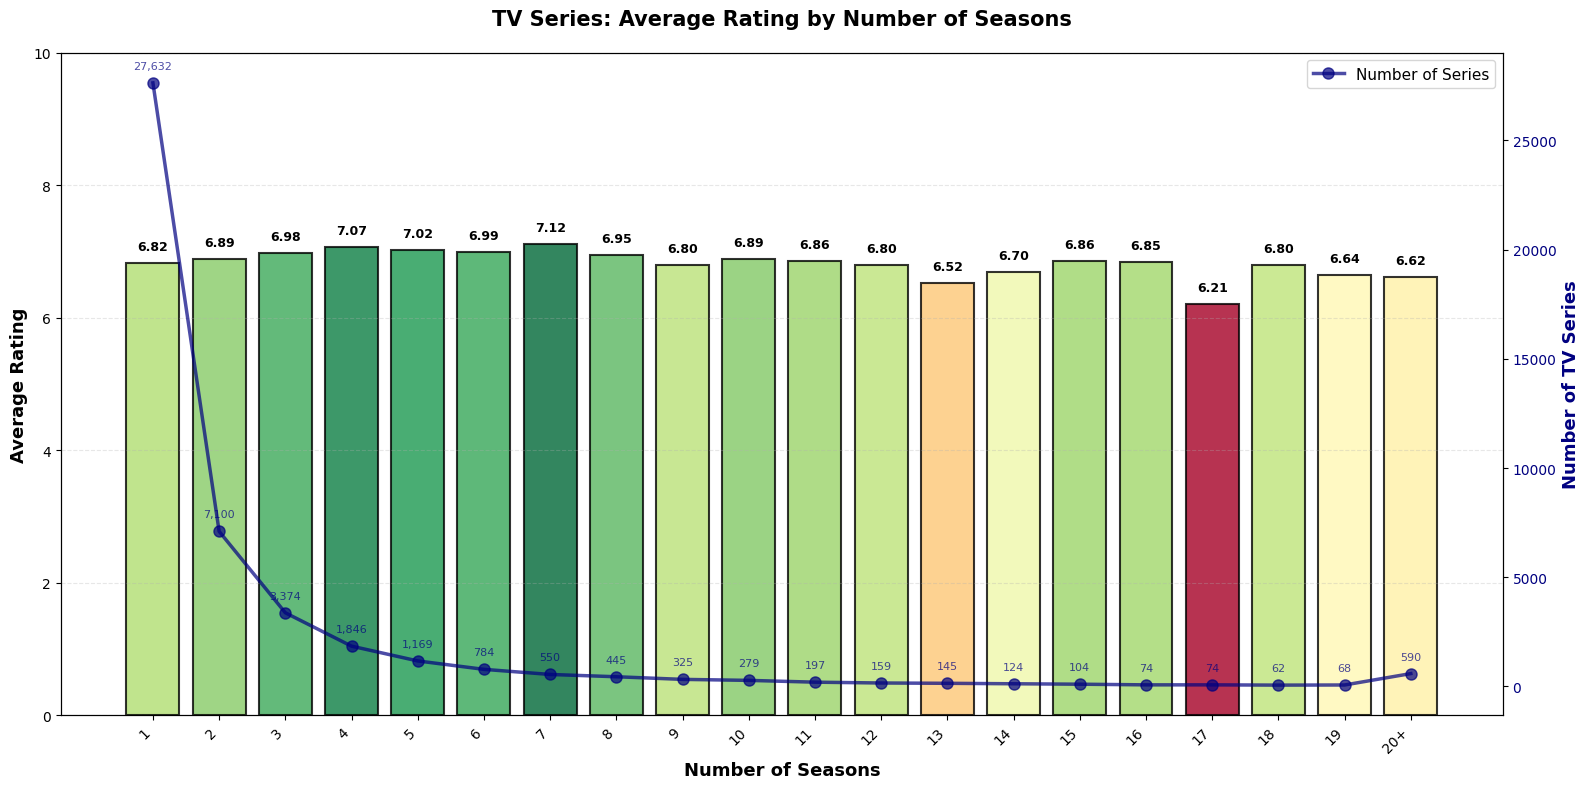

Correlation coefficient (seasons 1-19): 0.0153


+------------+------------------+-----+
|season_group|        avg_rating|count|
+------------+------------------+-----+
|           7| 7.115090912472118|  550|
|          15| 6.855769249109121|  104|
|          11| 6.857868036037774|  197|
|           3| 6.981209260264161| 3374|
|           8| 6.947865176468753|  445|
|          16| 6.848648670557383|   74|
|        NULL| 6.084011847491092| 1351|
|           5| 7.022668952305568| 1169|
|          18|6.7983871083105765|   62|
|          17|  6.20810809489843|   74|
|           6|  6.98903062833207|  784|
|          19| 6.641176451654995|   68|
|         20+| 6.617118660878327|  590|
|           9| 6.803384626461909|  325|
|           1| 6.822419663704609|27632|
|          10| 6.893189949374045|  279|
|           4| 7.070151689638942| 1846|
|          12| 6.801886778957439|  159|
|          13| 6.524137934323015|  145|
|          14| 6.697580635547638|  124|
+------------+------------------+-----+
only showing top 20 rows


In [6]:
result = correlation_seasons_rating(dataframes, save_path="./output")
result.show()


### Top Episodes by Votes and Rating


Filtering by top 5 regions: DE, FR, JP, IN, ES


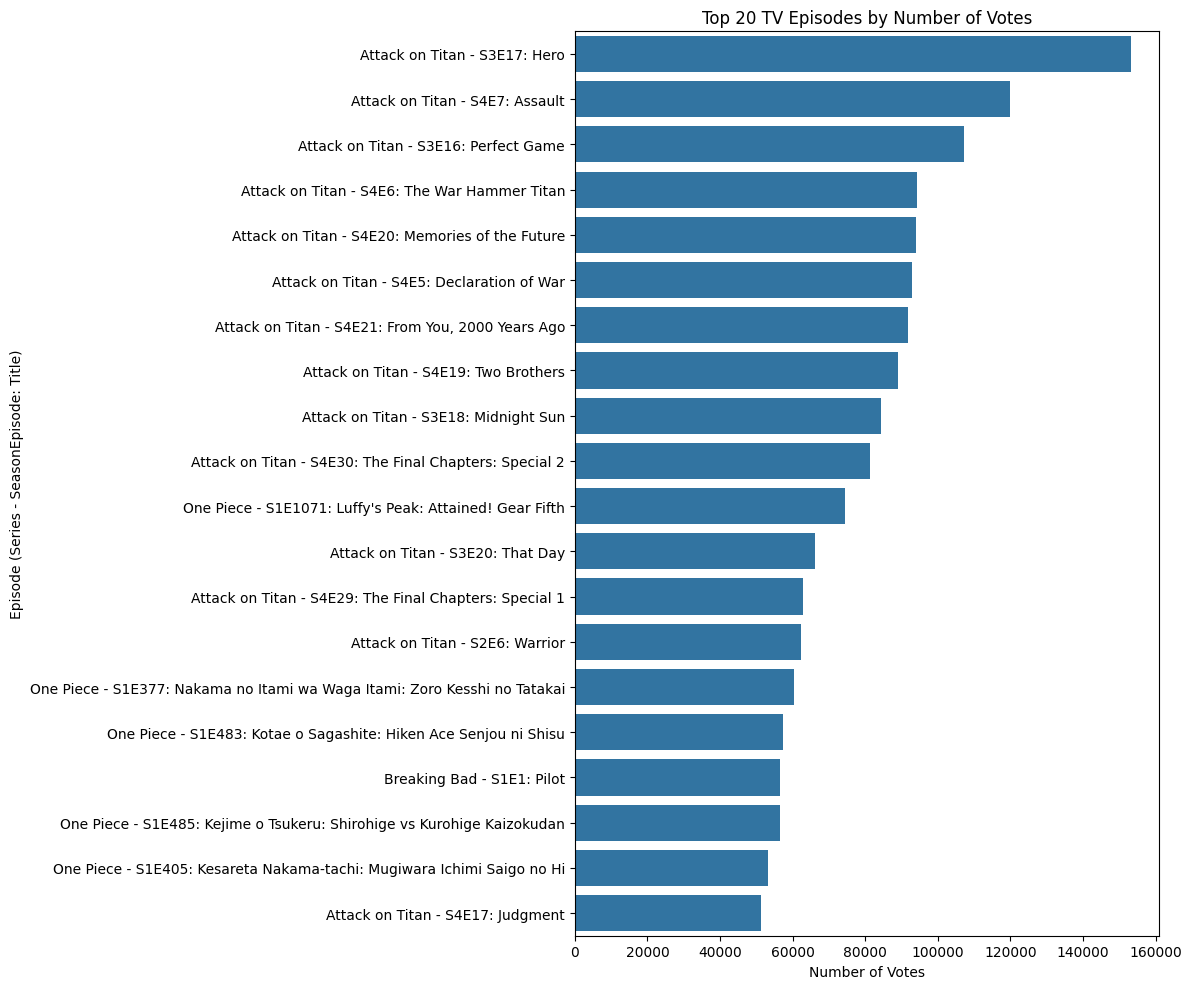

+----------+--------------------+---------------+------------+-------------+--------+-------------+
|    tconst|        episodeTitle|    seriesTitle|seasonNumber|episodeNumber|numVotes|averageRating|
+----------+--------------------+---------------+------------+-------------+--------+-------------+
| tt9906260|                Hero|Attack on Titan|           3|           17|  153258|          9.8|
|tt13857684|             Assault|Attack on Titan|           4|            7|  119955|          9.8|
| tt9898836|        Perfect Game|Attack on Titan|           3|           16|  107139|          9.8|
|tt13819632|The War Hammer Titan|Attack on Titan|           4|            6|   94175|          9.8|
|tt17505964|Memories of the F...|Attack on Titan|           4|           20|   94014|          9.8|
|tt13605714|  Declaration of War|Attack on Titan|           4|            5|   92967|          9.8|
|tt17594170|From You, 2000 Ye...|Attack on Titan|           4|           21|   91873|          9.8|


In [7]:
result = top_episodes_by_votes_and_rating(dataframes, save_path="./output")
result.show()


### Genre Influence on Seasons


Filtering by top 5 regions: DE, FR, JP, IN, ES


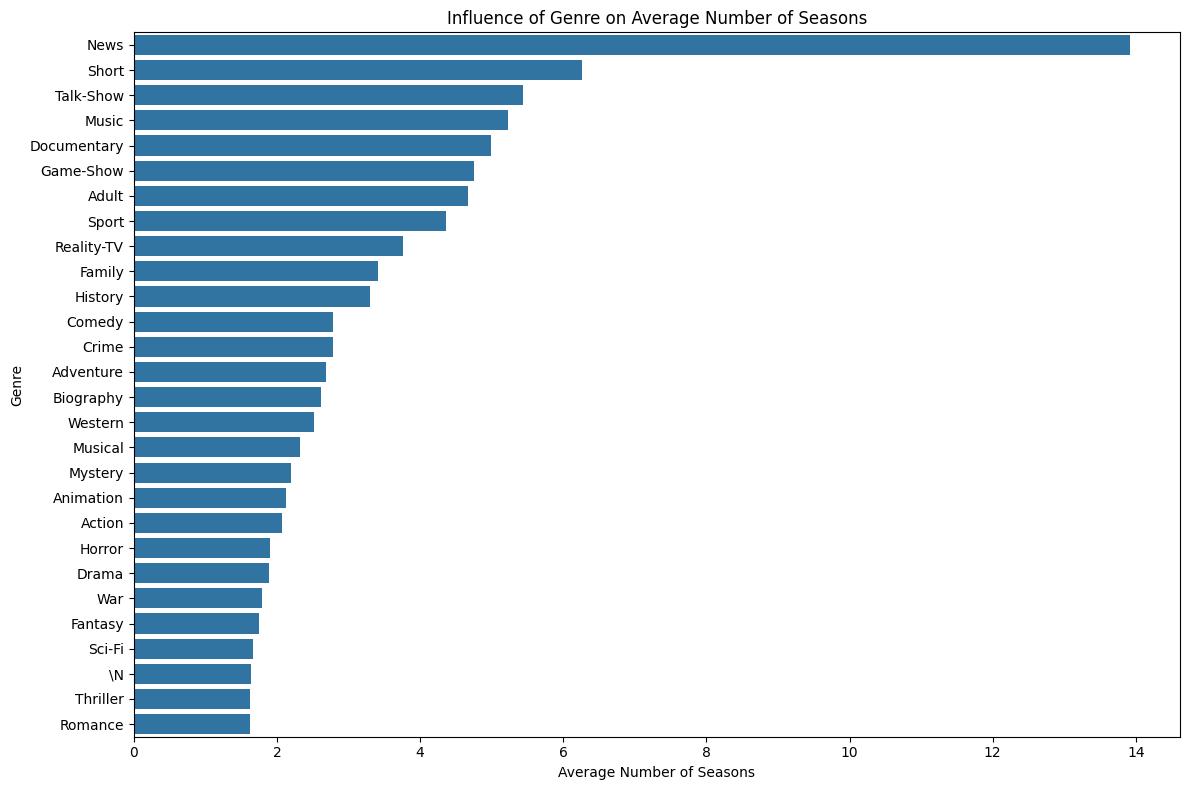

+-----------+------------------+-----------+-----------+----------+
|      genre|       avg_seasons|max_seasons|min_seasons|num_series|
+-----------+------------------+-----------+-----------+----------+
|       News|13.920289855072463|       2021|          1|      1211|
|      Short|6.2591093117408905|       2015|          1|       600|
|  Talk-Show| 5.432748538011696|       2024|          1|      3163|
|      Music| 5.234011627906977|       2017|          1|      1832|
|Documentary|4.9853015712113535|       2024|          1|      6841|
|  Game-Show|4.7543969849246235|         92|          1|      1864|
|      Adult| 4.666666666666667|        140|          1|       245|
|      Sport|  4.35673839184598|         94|          1|      1015|
| Reality-TV| 3.764127764127764|        271|          1|      4710|
|     Family| 3.408607863974495|       2021|          1|      3988|
|    History|3.3035502958579883|       2011|          1|      1746|
|     Comedy| 2.787776988177531|       2021|    

In [8]:
result = genre_seasons_influence(dataframes, save_path="./output")
result.show()


### Average Rating of Long Series



BUSINESS QUESTION: Average rating of series with 50+ episodes


Filtering by top 5 regions: DE, FR, JP, IN, ES

Series with 50+ episodes:


Series count: 11360


Average rating: 6.79

Top-10 long series with highest ratings:


+----------------------+-------------+-------------+--------+
|primaryTitle          |episode_count|averageRating|numVotes|
+----------------------+-------------+-------------+--------+
|Gundeninda Gudigantalu|469          |10.0         |6       |
|The Life Series       |57           |9.8          |166     |
|Choufli Hal           |135          |9.6          |3274    |
|Amrutham              |61           |9.6          |1036    |
|Coke Studio Pakistan  |109          |9.6          |1377    |
|Friday Five Sharp     |74           |9.6          |4571    |
|Marmadesam            |238          |9.6          |1011    |
|Kino+                 |401          |9.5          |295     |
|The Why Files         |210          |9.5          |1152    |
|Breaking Bad          |62           |9.5          |2421795 |
+----------------------+-------------+-------------+--------+



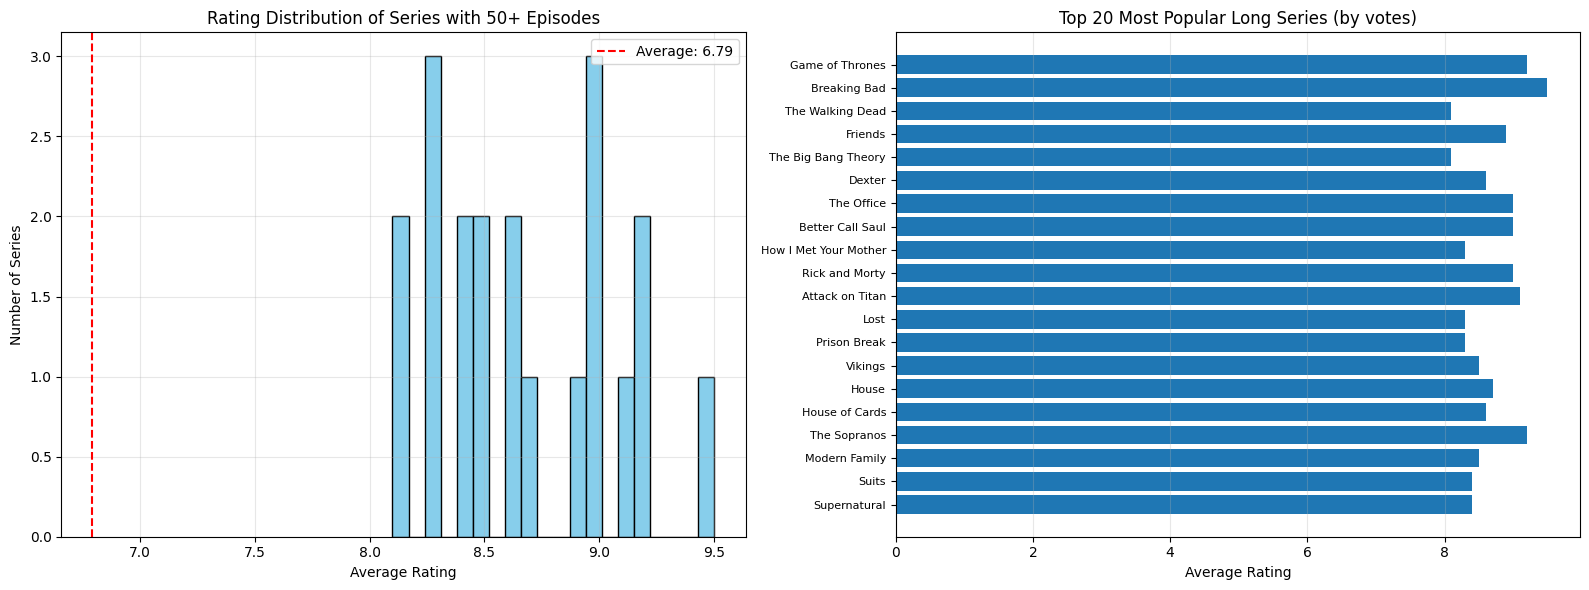

+------------------+------------+
|        avg_rating|series_count|
+------------------+------------+
|6.7948327536943935|       11360|
+------------------+------------+



In [9]:
result = avg_rating_long_series(dataframes, save_path="./output")
result.show()


### Season Rating Differences



BUSINESS QUESTION: Season rating dynamics for series with 3+ seasons


Filtering by top 5 regions: DE, FR, JP, IN, ES

Series with highest rating growth between seasons:


+---------------------------------------+------------+-----------------+------------------+-----------+
|primaryTitle                           |seasonNumber|season_avg_rating|prev_season_rating|rating_diff|
+---------------------------------------+------------+-----------------+------------------+-----------+
|Come Dine with Me                      |37          |9.8              |1.83              |7.98       |
|The Merv Griffin Show                  |22          |9.2              |1.3               |7.9        |
|SexTV                                  |7           |8.5              |1.15              |7.35       |
|The Talk                               |8           |8.1              |1.0               |7.1        |
|Dinah!                                 |3           |9.55             |2.8               |6.75       |
|The Doctors                            |7           |7.75             |1.0               |6.75       |
|Watch What Happens Live with Andy Cohen|11          |7.8       

+------------------------+------------+-----------------+------------------+-----------+
|primaryTitle            |seasonNumber|season_avg_rating|prev_season_rating|rating_diff|
+------------------------+------------+-----------------+------------------+-----------+
|The Doctors             |6           |1.0              |10.0              |-9.0       |
|The David Frost Show    |4           |1.2              |9.7               |-8.5       |
|Loose Women             |21          |1.0              |9.3               |-8.3       |
|SportsCenter            |39          |1.6              |9.6               |-8.0       |
|The Playboy Morning Show|7           |1.7              |9.4               |-7.7       |
|Live with Kelly and Mark|29          |1.0              |8.7               |-7.7       |
|Pinoy Big Brother       |11          |1.0              |8.5               |-7.5       |
|Entertainment Tonight   |36          |1.0              |8.2               |-7.2       |
|The Talk            

/usr/local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


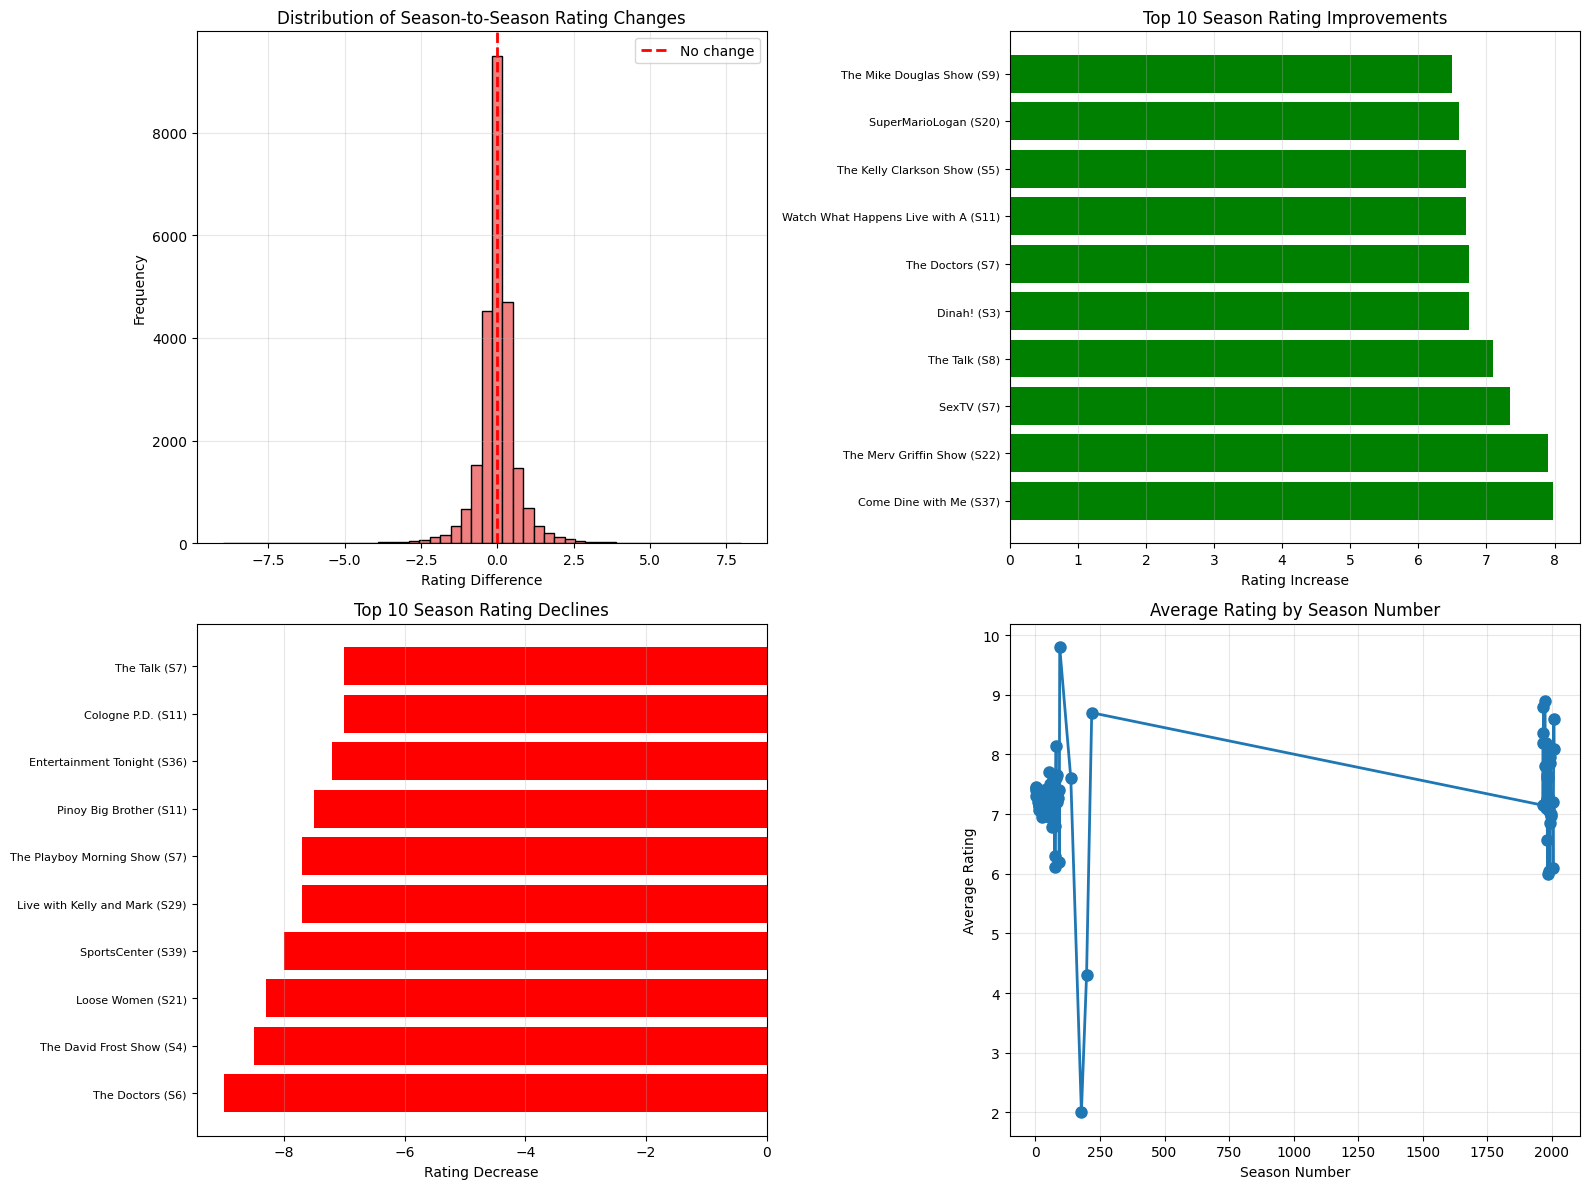

+------------+------------+------------------+----------+------------------+--------------------+---------+--------------------+
|parentTconst|seasonNumber| season_avg_rating|max_season|prev_season_rating|         rating_diff|   tconst|        primaryTitle|
+------------+------------+------------------+----------+------------------+--------------------+---------+--------------------+
|   tt0040048|           9|               8.0|         9|              NULL|                NULL|tt0040048|Perry Como's Kraf...|
|   tt0042098|           2|               5.5|         5|              NULL|                NULL|tt0042098|              Danger|
|   tt0042098|           3| 7.599999904632568|         5|               5.5|  2.0999999046325684|tt0042098|              Danger|
|   tt0042098|           5|              7.25|         5| 7.599999904632568|-0.34999990463256836|tt0042098|              Danger|
|   tt0042168|           1|  8.38888888888889|        18|              NULL|                NULL|

In [10]:
result = season_rating_diff(dataframes, save_path="./output")
result.show()


### Hook Shows (Rating Growth)


Analyzing hook shows for regions: ['DE', 'FR', 'JP', 'IN', 'ES']


Filtering by top 5 regions: DE, FR, JP, IN, ES


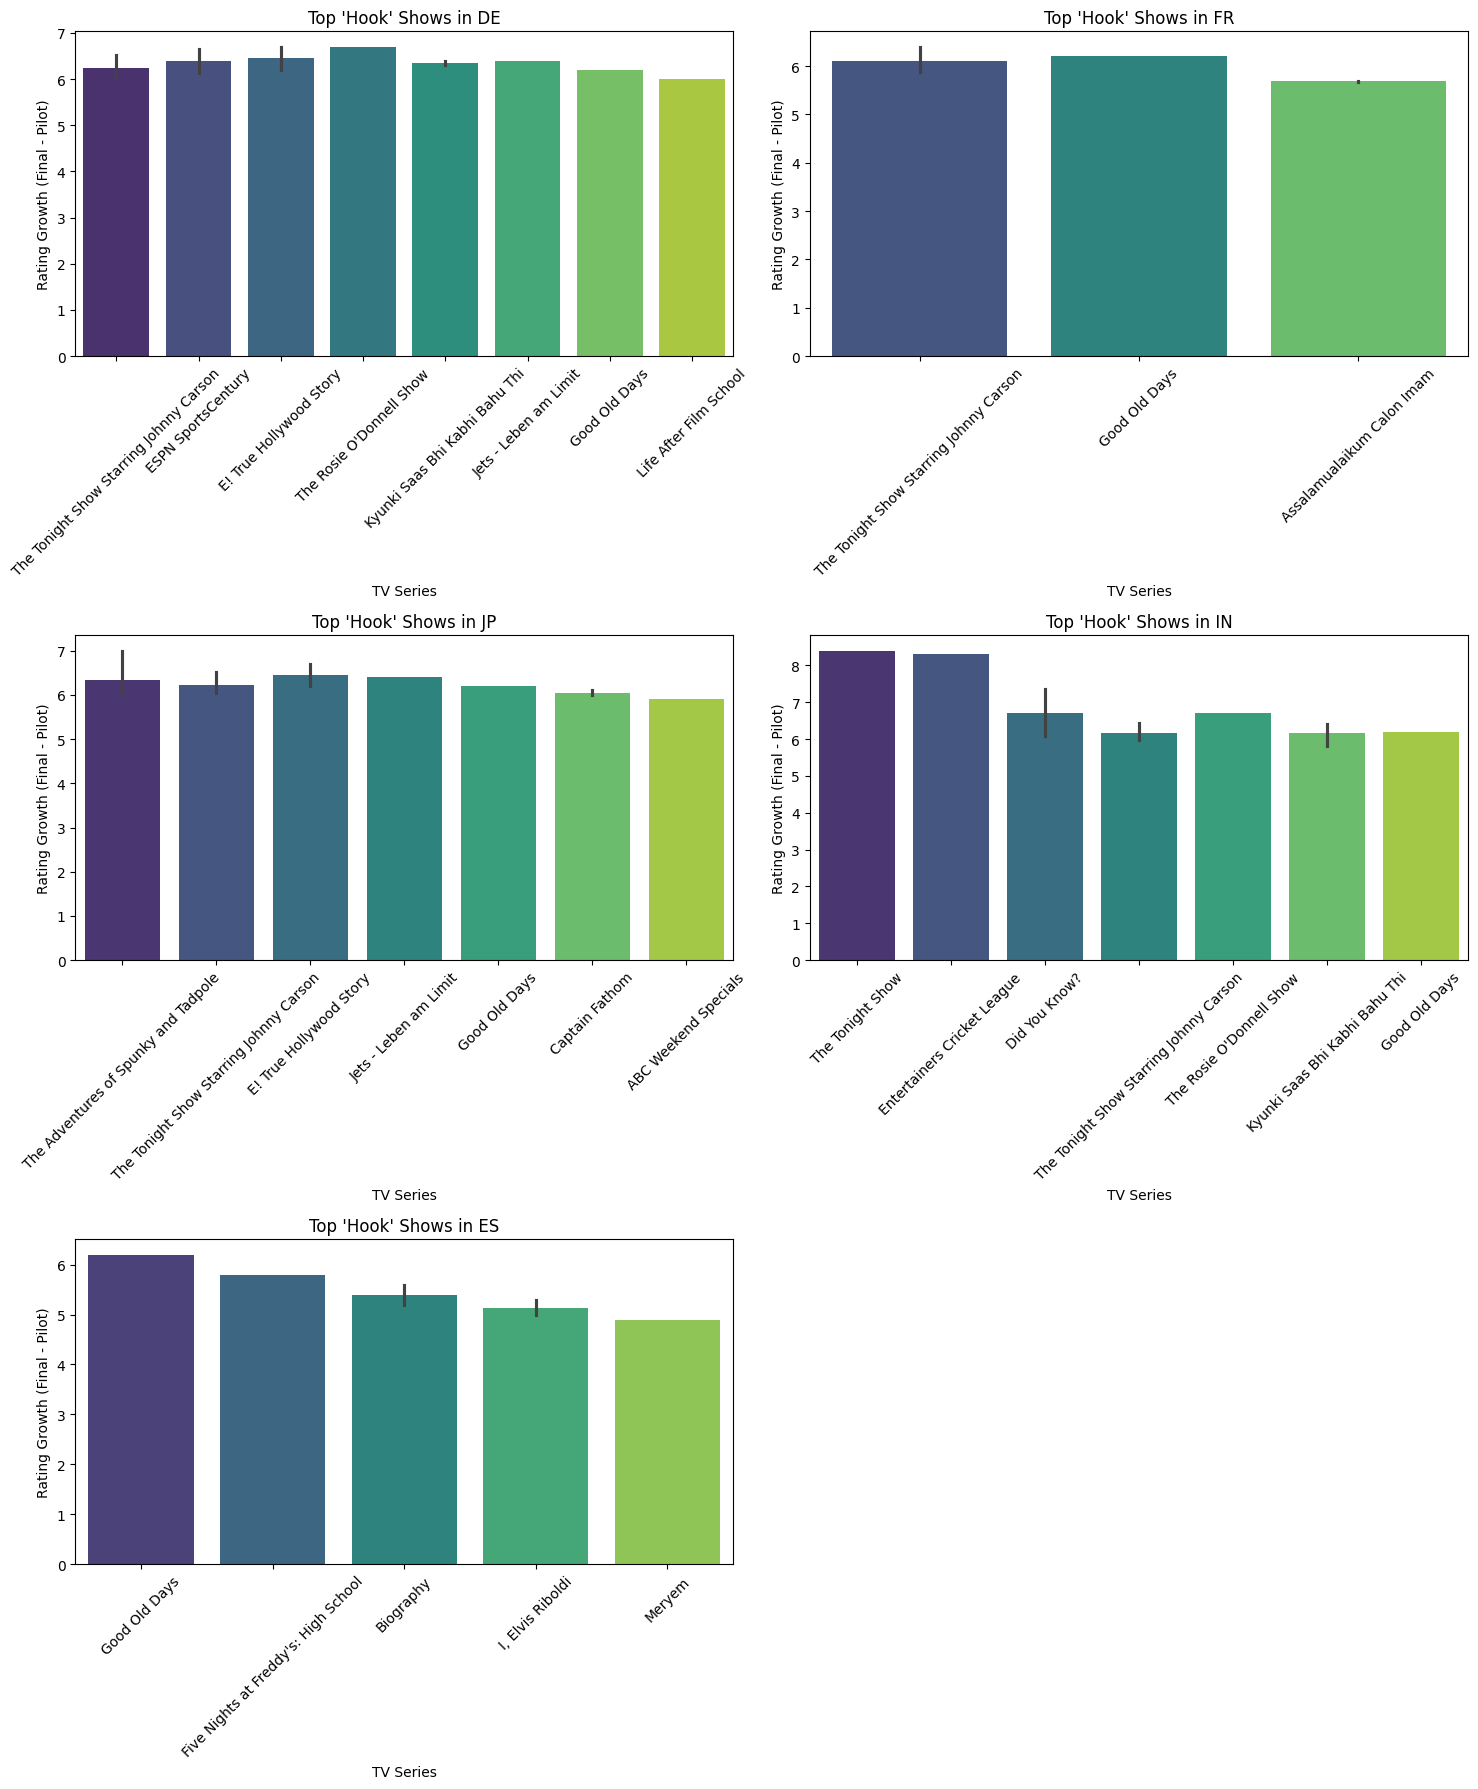

+------+--------------------+------------+-----------+------------+
|region|        primaryTitle|first_rating|last_rating|delta_rating|
+------+--------------------+------------+-----------+------------+
|    DE|The Tonight Show ...|         2.8|        9.7|   6.8999996|
|    DE|  ESPN SportsCentury|         2.8|        9.6|         6.8|
|    DE|E! True Hollywood...|         2.3|        9.0|         6.7|
|    DE|The Rosie O'Donne...|         2.5|        9.2|         6.7|
|    DE|  ESPN SportsCentury|         2.8|        9.4|   6.5999994|
|    DE|  ESPN SportsCentury|         2.8|        9.3|         6.5|
|    DE|Kyunki Saas Bhi K...|         3.2|        9.6|   6.4000006|
|    DE|Jets - Leben am L...|         3.6|       10.0|         6.4|
|    DE|The Tonight Show ...|         2.8|        9.1|         6.3|
|    DE|Kyunki Saas Bhi K...|         3.2|        9.5|         6.3|
|    DE|       Good Old Days|         3.6|        9.8|   6.2000003|
|    DE|       Good Old Days|         3.6|      

In [11]:
result = hook_shows(dataframes, save_path="./output")
result.show()


### Sophomore Slump


Filtering by top 5 regions: DE, FR, JP, IN, ES


/app/analysis/tv_analysis.py:724: FutureWarning:                                

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_pd, x="main_genre", y="avg_delta", palette="coolwarm")


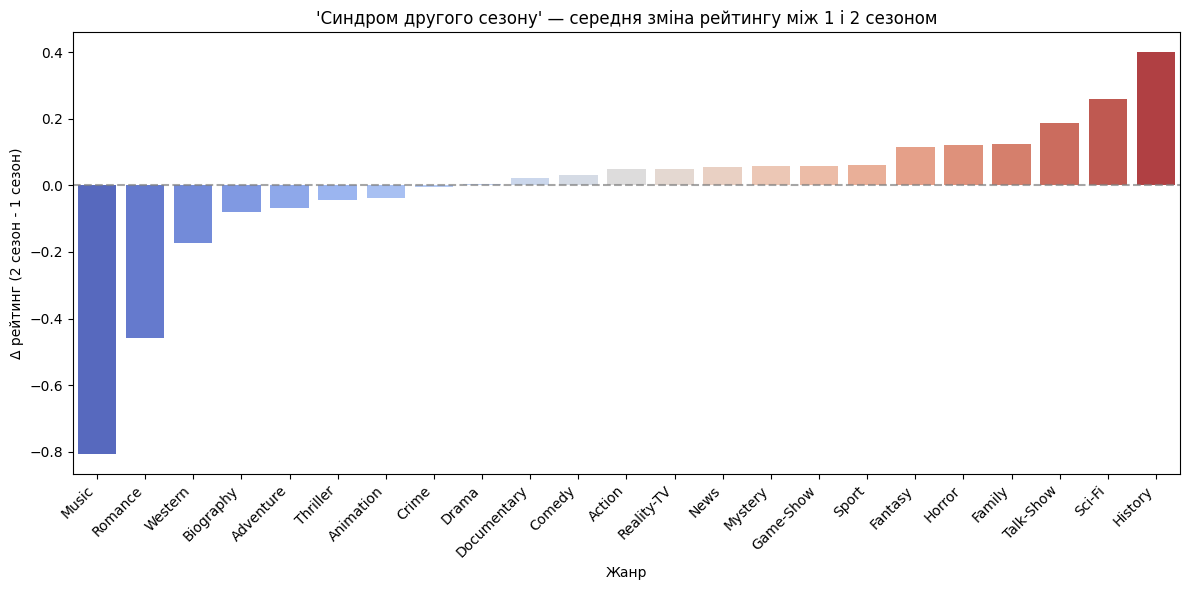

In [27]:
result = sophomore_slump(dataframes, save_path="./output")

---
# Genre Analysis


### Genre Popularity Trend


Analyzing movies from 2015 to 2025 (10 years)


Analyzing top 5 regions: US, GB, CA, IN, DE


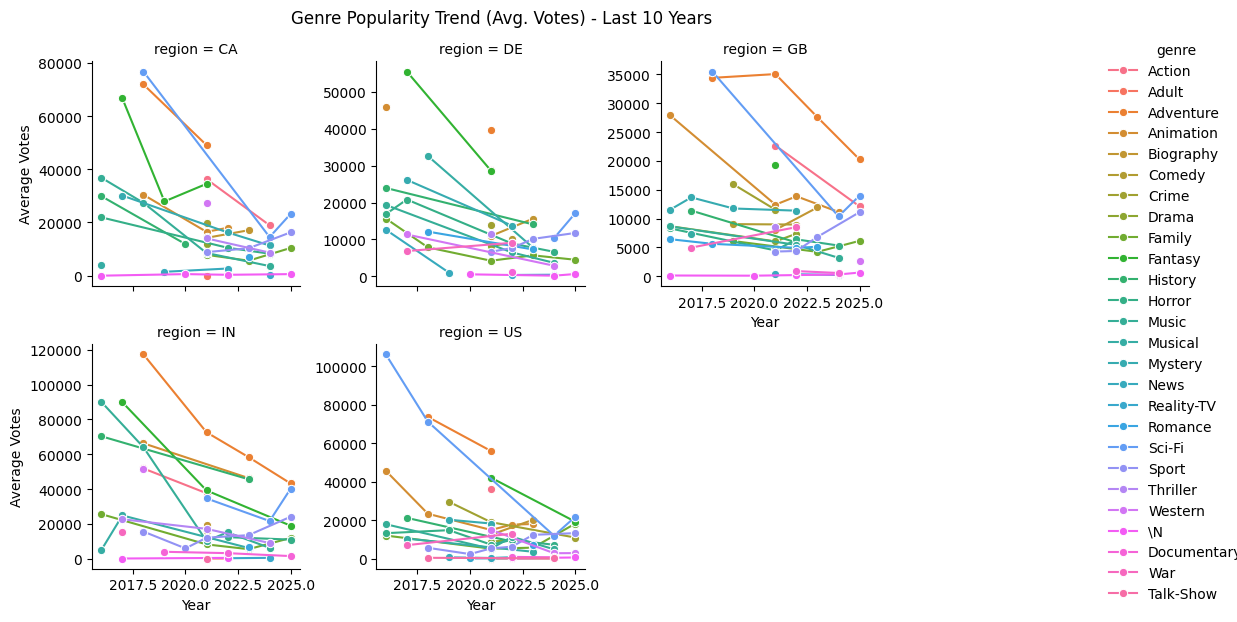

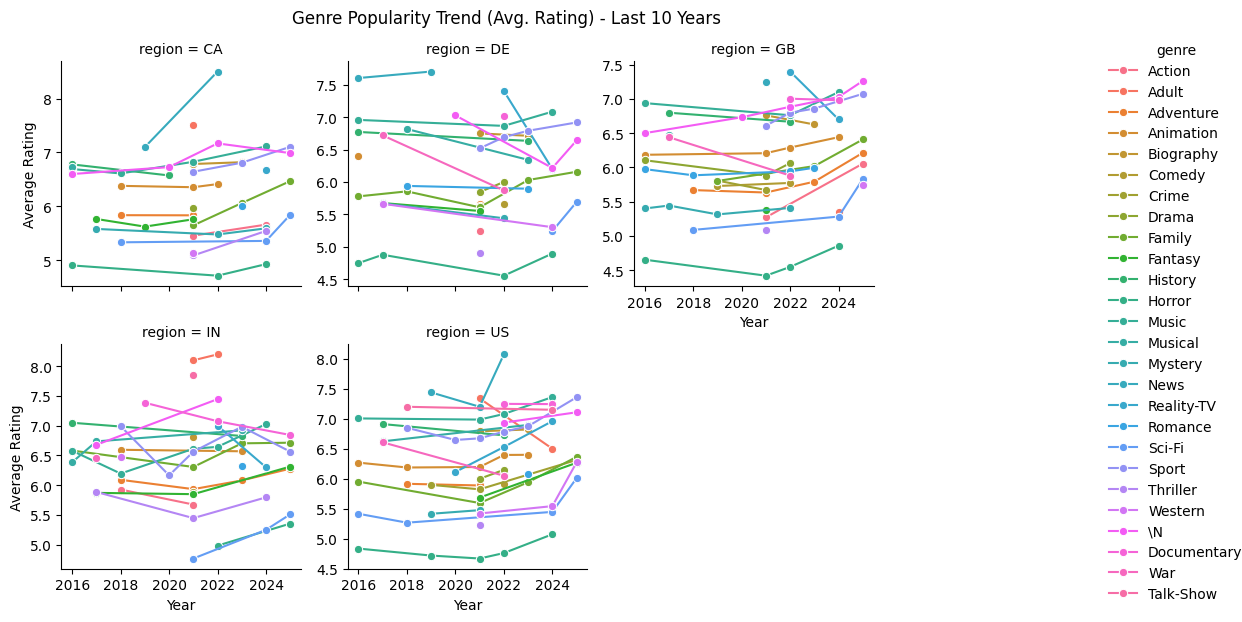

+------+-----------+---------+------------------+------------------+------------------+------------------+
|region|      genre|startYear|         avg_votes|        avg_rating|   prev_year_votes|  prev_year_rating|
+------+-----------+---------+------------------+------------------+------------------+------------------+
|    AD|     Action|     2025|           85118.0| 6.400000095367432|             450.0| 5.699999809265137|
|    AD|      Crime|     2025|           85118.0| 6.400000095367432|             305.0| 4.699999809265137|
|    AD|Documentary|     2021|              34.0| 9.399999618530273|              16.0|               7.0|
|    AE|     Action|     2023|           38904.1| 6.410000038146973|33278.663817663815| 5.408831914945206|
|    AE|  Adventure|     2018| 174026.3137254902| 6.435294113907159|          151545.3| 5.797499978542328|
|    AE|  Adventure|     2025|            3207.0| 8.100000381469727| 481.3333333333333| 6.733333349227905|
|    AE|  Animation|     2018|131782.

In [13]:
result = genre_popularity_trend(dataframes, save_path="./output")
result.show()


### Genre Actor Cyclicality


Analyzing movies from 1894 to 2032 in 10-year steps.


Analyzing top 5 regions: US, GB, CA, IN, JP


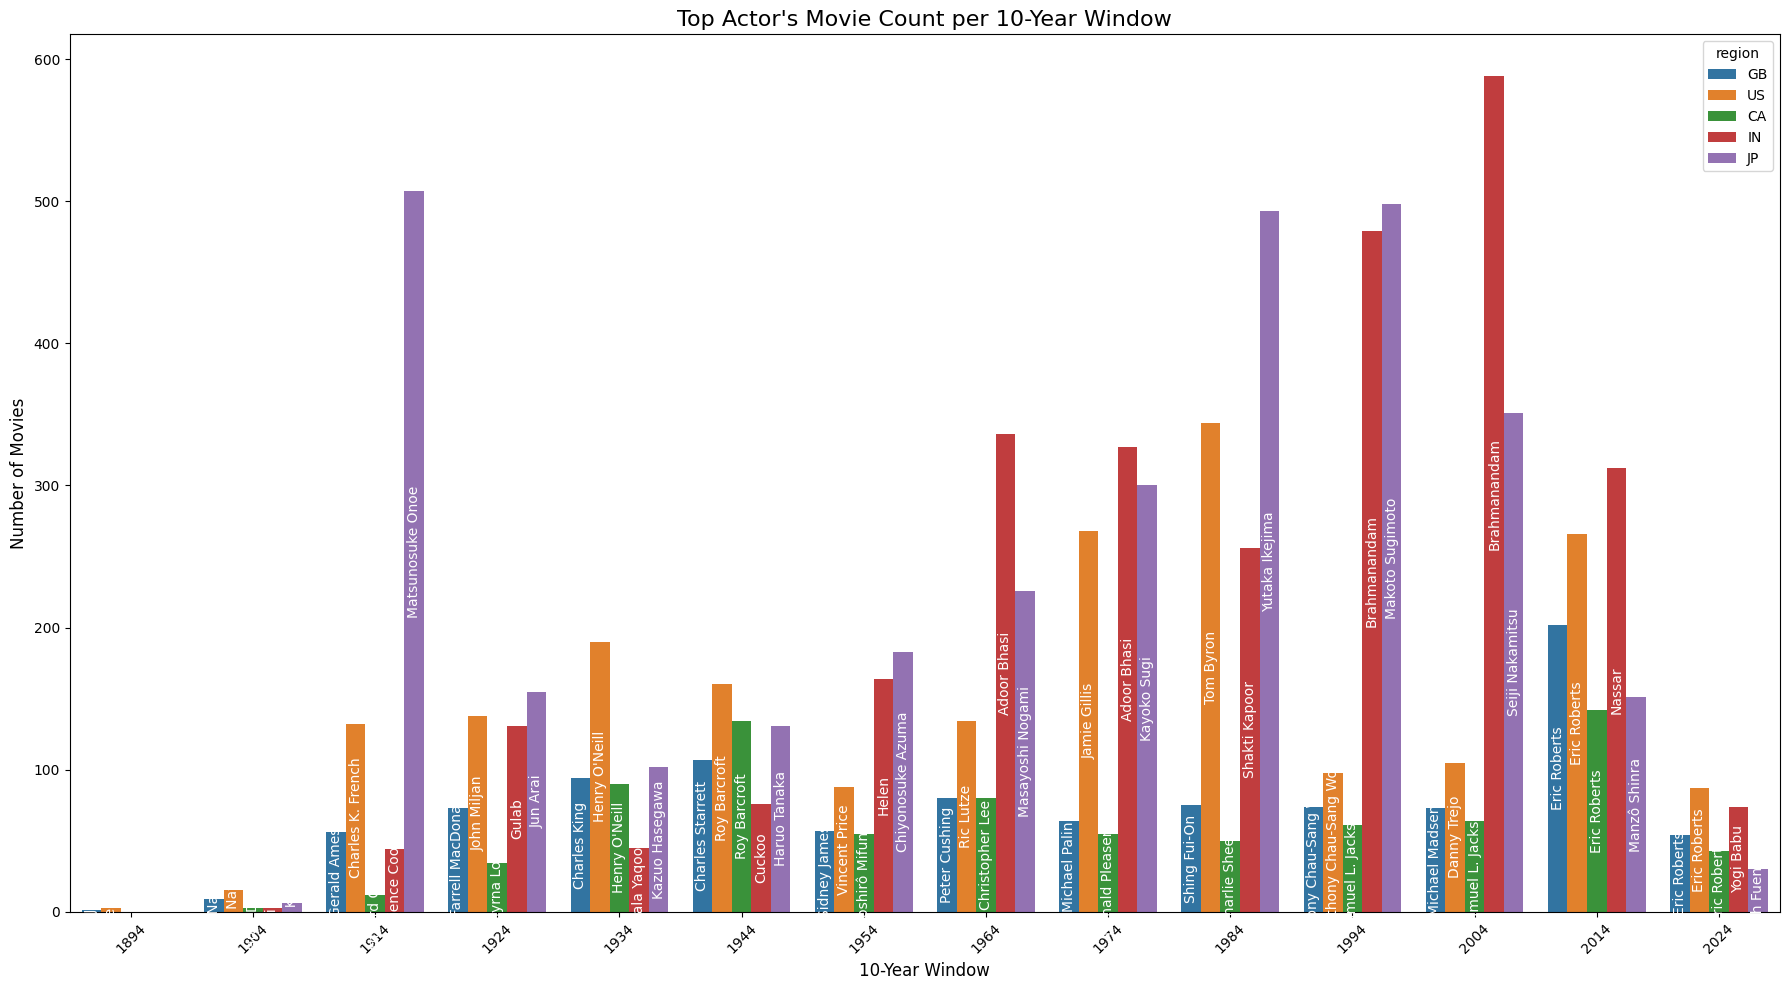

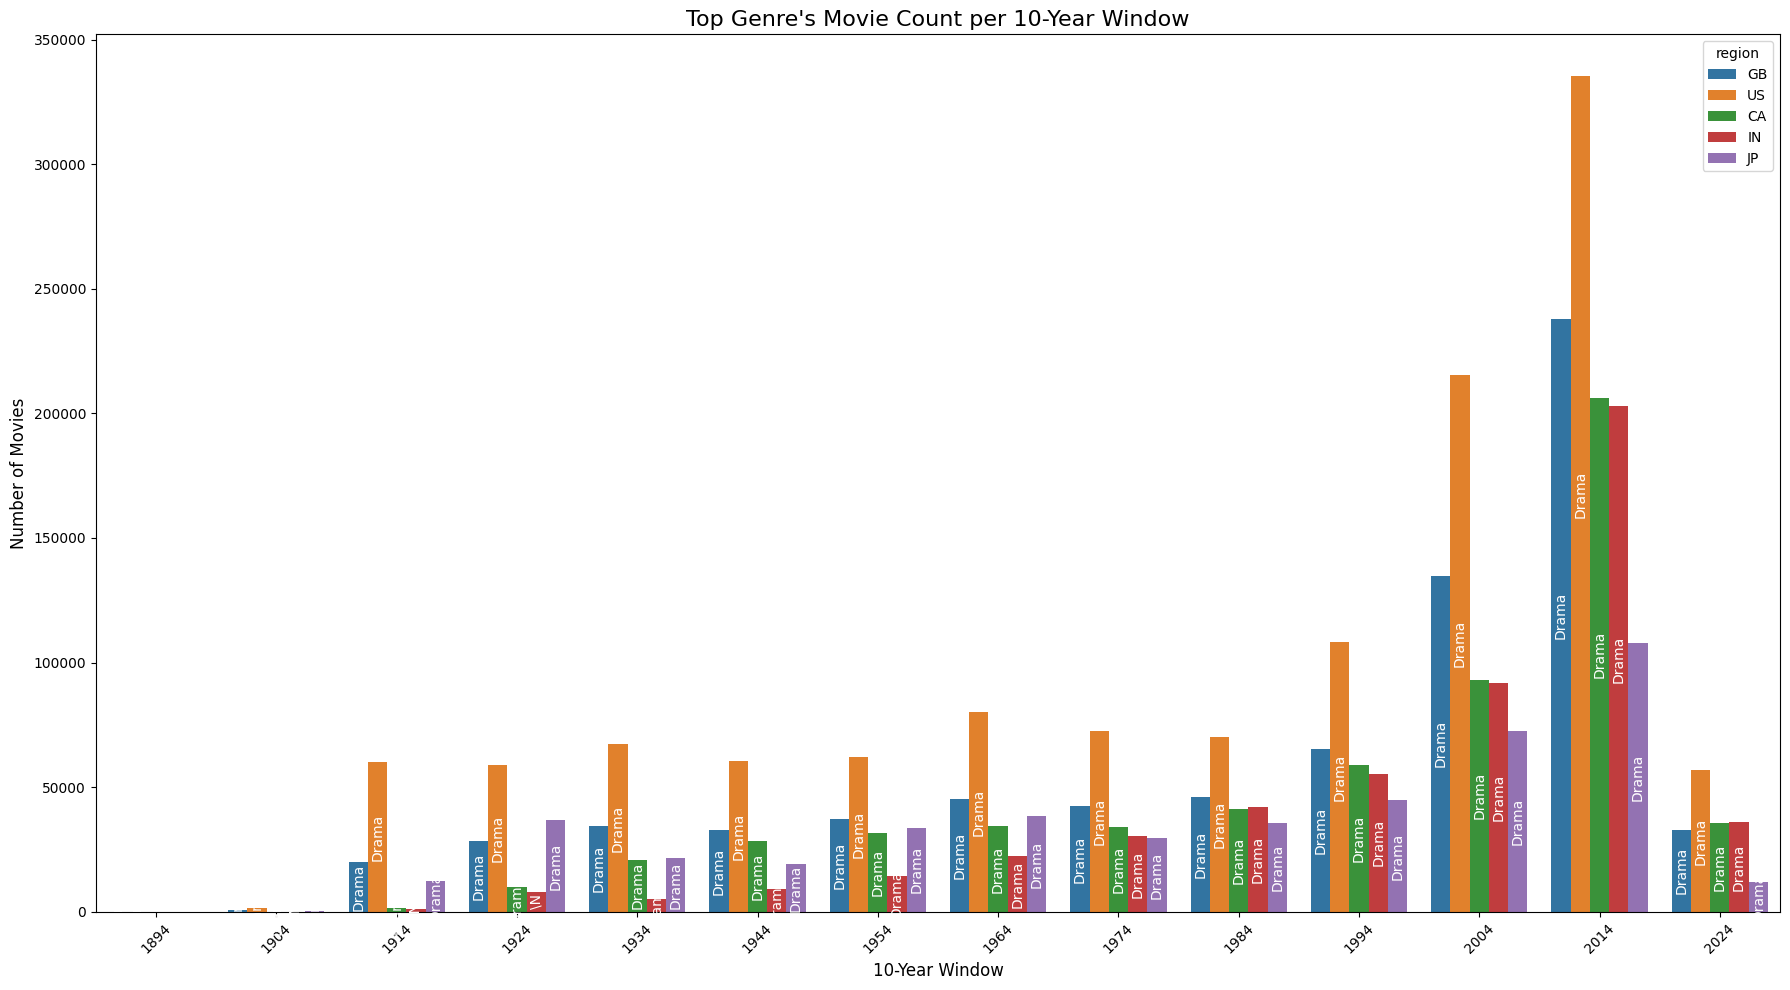

In [26]:
result = genre_actor_cyclicality(dataframes, save_path="./output")


### Genre Duration vs Rating Analysis


Filtering by top 5 regions: DE, FR, JP, IN, ES
Analyzing movies from all available years


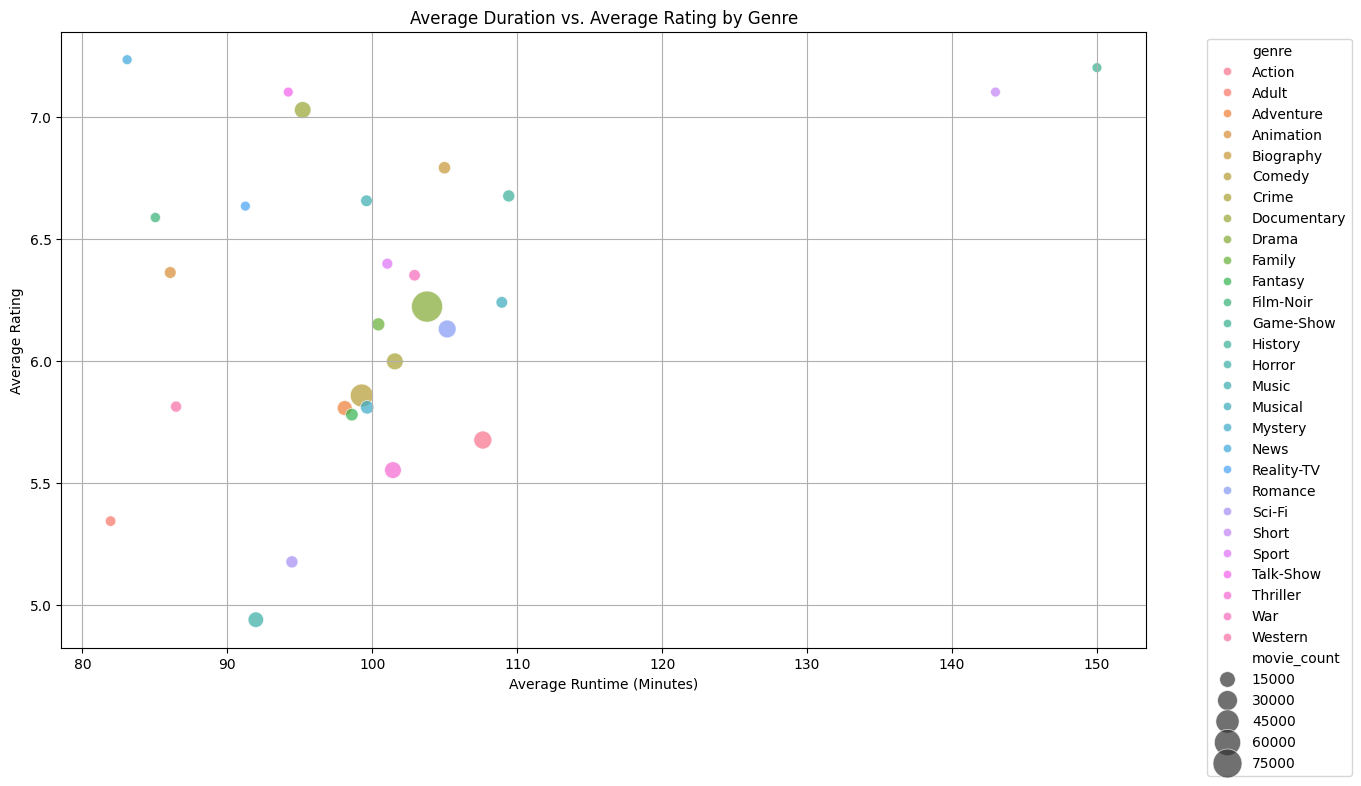

+-----------+------------------+------------------+-----------+
|      genre|       avg_runtime|        avg_rating|movie_count|
+-----------+------------------+------------------+-----------+
|     Action| 107.6237243703773| 5.676249944420898|      23061|
|      Adult|  81.9387430389817| 5.344338242183714|       1360|
|  Adventure|  98.0946484959282| 5.807059295016986|      12480|
|  Animation| 86.05510254509514| 6.361651986957987|       4201|
|  Biography|104.97745901639344| 6.790491803074578|       5490|
|     Comedy|    99.26749288711|  5.85842200368367|      43232|
|      Crime|101.55209206189598| 5.998009468352433|      18588|
|Documentary| 95.19385532500287| 7.026933166405529|      18312|
|      Drama|103.77501477309728| 6.222238432116516|      87740|
|     Family|100.41427709025052| 6.149497911321568|       7170|
|    Fantasy| 98.58547150949684|  5.78009646563668|       6220|
|  Film-Noir| 85.02691218130312| 6.586685552475473|        706|
|  Game-Show|             150.0| 7.19999

In [15]:
result = genre_duration_rating_analysis(dataframes, save_path="./output")
result.show()


### Genre Evolution Analysis



BUSINESS QUESTION: Genre Evolution Analysis (Before vs After 2010)


Filtering by top 5 regions: DE, FR, JP, IN, ES

Comparing periods:
  BEFORE: 2000-2010
  AFTER:  2011-2023

GENRE EVOLUTION RANKINGS

🚀 TOP 5 RISING GENRES (Highest Momentum):


+-----------+-------------+--------+-------------------+--------+
|genre      |film_growth_%|rating_Δ|engagement_growth_%|momentum|
+-----------+-------------+--------+-------------------+--------+
|Biography  |287.5        |0.0     |-53.0              |117.2   |
|History    |273.9        |-0.04   |-38.0              |115.9   |
|Documentary|246.9        |-0.09   |-37.5              |100.2   |
|Sci-Fi     |225.0        |-0.14   |-47.6              |81.9    |
|Sport      |188.8        |0.32    |-65.4              |77.5    |
+-----------+-------------+--------+-------------------+--------+


📉 TOP 5 DECLINING GENRES (Lowest Momentum):


+-------+-------------+--------+-------------------+--------+
|genre  |film_growth_%|rating_Δ|engagement_growth_%|momentum|
+-------+-------------+--------+-------------------+--------+
|War    |97.6         |-0.34   |-59.9              |1.7     |
|Romance|71.5         |0.04    |-52.1              |11.7    |
|Musical|40.0         |0.35    |-42.2              |16.6    |
|Crime  |95.8         |0.0     |-43.0              |26.4    |
|Comedy |111.3        |-0.02   |-42.2              |33.6    |
+-------+-------------+--------+-------------------+--------+



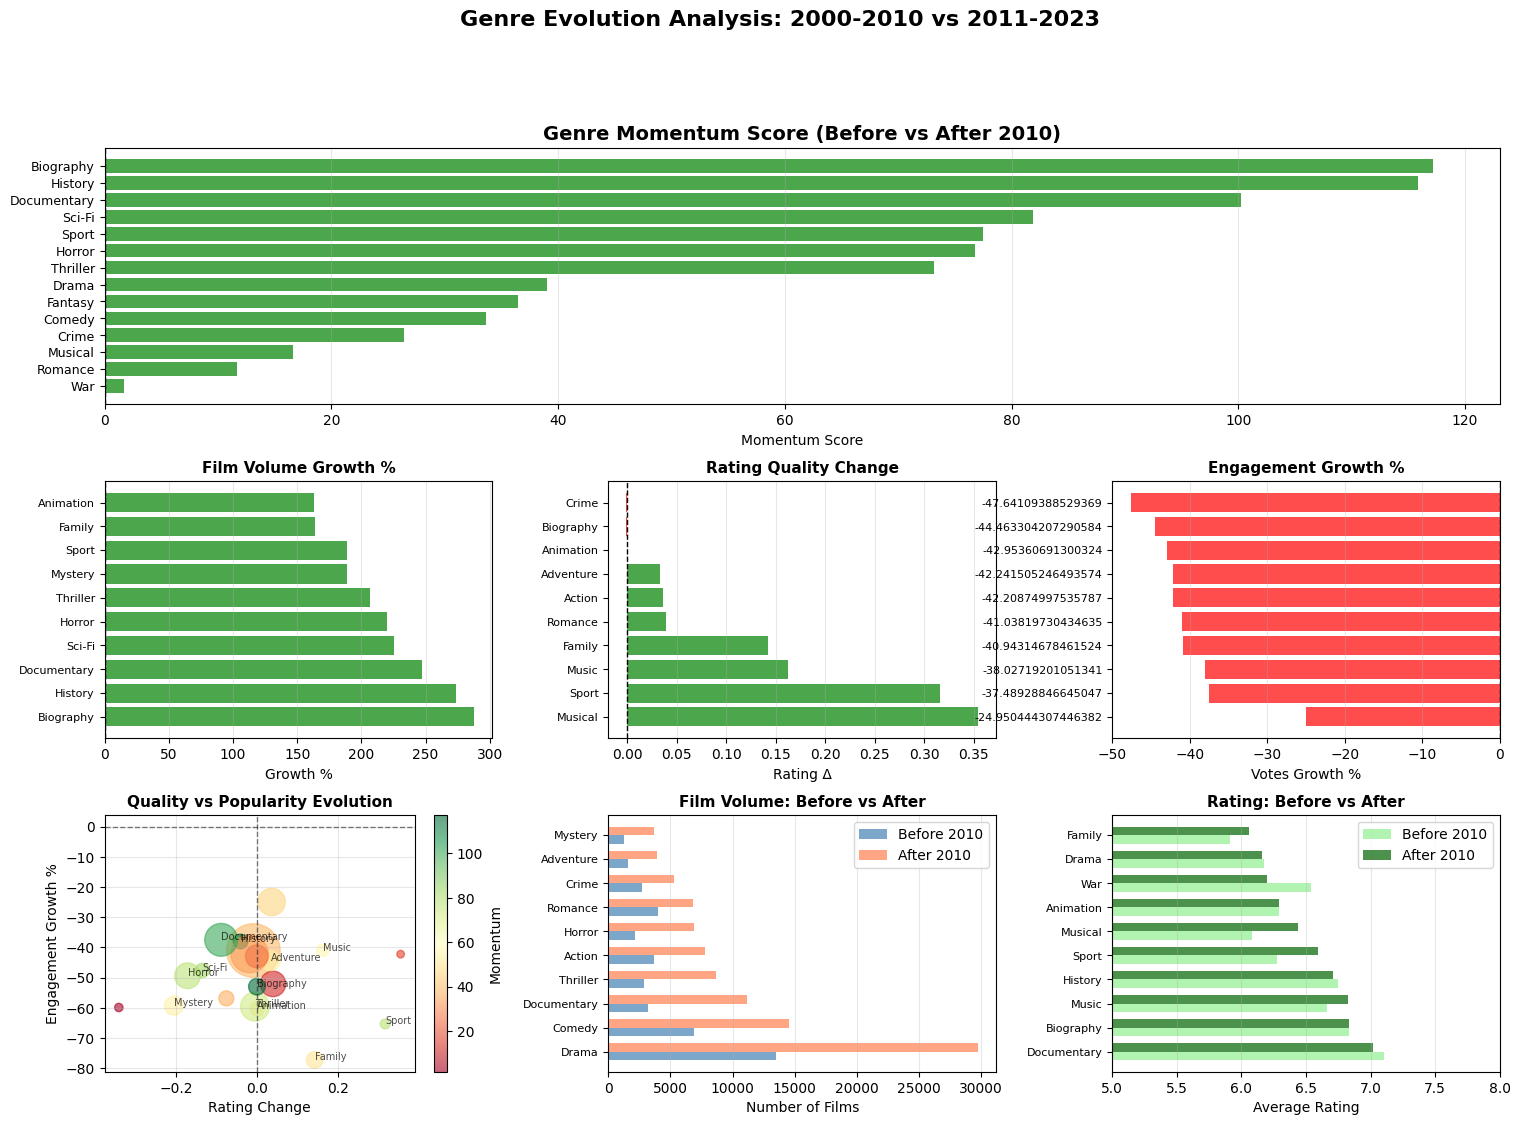

+-----------+------------+------------------+------------------+-----------+------------------+------------------+------------------+--------------------+---------------------+------------------+
|      genre|films_before|     rating_before|      votes_before|films_after|      rating_after|       votes_after|   film_growth_pct|       rating_change|engagement_growth_pct|    momentum_score|
+-----------+------------+------------------+------------------+-----------+------------------+------------------+------------------+--------------------+---------------------+------------------+
|     Horror|        2146| 4.862208755629593|15120.831780055918|       6873|4.6897715700430656| 7652.686890731849|220.27027027027026|-0.17243718558652787|   -49.38977562844397| 76.81838804158676|
|    Musical|         432| 6.084953701330556|  7931.19212962963|        605|6.4395041367239205|4580.9371900826445|  40.0462962962963|  0.3545504353933646|  -42.241505246493574| 16.62991729456959|
|  Animation|       

In [16]:
result = genre_evolution_analysis(dataframes, save_path="./output")
result.show()


### Genre Combinations Analysis



BUSINESS QUESTION: Genre Combinations Analysis

Analyzing genre combinations with at least 50 films


Filtering by top 5 regions: DE, FR, JP, IN, ES

--------------------------------------------------------------------------------
TOP GENRE COMBINATIONS BY AVERAGE RATING:
--------------------------------------------------------------------------------


+-------------------------------+----------+------------------+------------------+
|genre_combination              |film_count|avg_rating        |avg_votes         |
+-------------------------------+----------+------------------+------------------+
|Documentary, Music             |765       |7.3611764784731895|1133.7960784313725|
|Documentary, History, Music    |58        |7.336206896551724 |1402.6724137931035|
|Biography, Documentary, Sport  |107       |7.2411214926532494|3957.8504672897197|
|Documentary, History           |415       |7.225060265897269 |1120.0795180722891|
|Documentary, History, War      |94        |7.217021272537556 |1075.712765957447 |
|Biography, Documentary, Drama  |152       |7.21513158553525  |1368.717105263158 |
|Documentary, News              |68        |7.210294137982761 |1565.735294117647 |
|Documentary, Sport             |313       |7.1884984132200005|1184.0575079872206|
|Biography, Documentary, Music  |268       |7.171641801720235 |1970.0597014925372|
|Doc

+----------------------------+----------+-----------------+-----------+
|genre_combination           |film_count|avg_rating       |total_votes|
+----------------------------+----------+-----------------+-----------+
|Action, Adventure, Sci-Fi   |241       |5.493360994267761|54523088   |
|Adventure, Animation, Comedy|622       |6.042604497391311|35065209   |
|Comedy, Drama, Romance      |2470      |6.132753036910223|34162006   |
|Action, Crime, Drama        |1569      |5.831612490407216|32062160   |
|Comedy, Drama               |4620      |6.173809522261351|27685931   |
|Action, Adventure, Fantasy  |281       |5.240213532040552|27627754   |
|Action, Adventure, Comedy   |554       |5.390252702933356|26990444   |
|Drama, Romance              |3656      |6.232221006434125|25922726   |
|Crime, Drama, Thriller      |1106      |6.050452078660617|25886739   |
|Crime, Drama, Mystery       |721       |6.095284315650241|21846428   |
|Comedy, Romance             |2170      |5.692580643447314|21480

/app/analysis/genre_analysis.py:704: FutureWarning:                             

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rating_pd.head(10), y='genre_combination', x='avg_rating',
/app/analysis/genre_analysis.py:715: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pop_plot, y='genre_combination', x='total_votes_millions',
/app/analysis/genre_analysis.py:724: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_engagement_pd.head(10), y='genre_combination', x='engagement_score',
/app/analysis/genre_analysis.py:749: FutureWarning:     

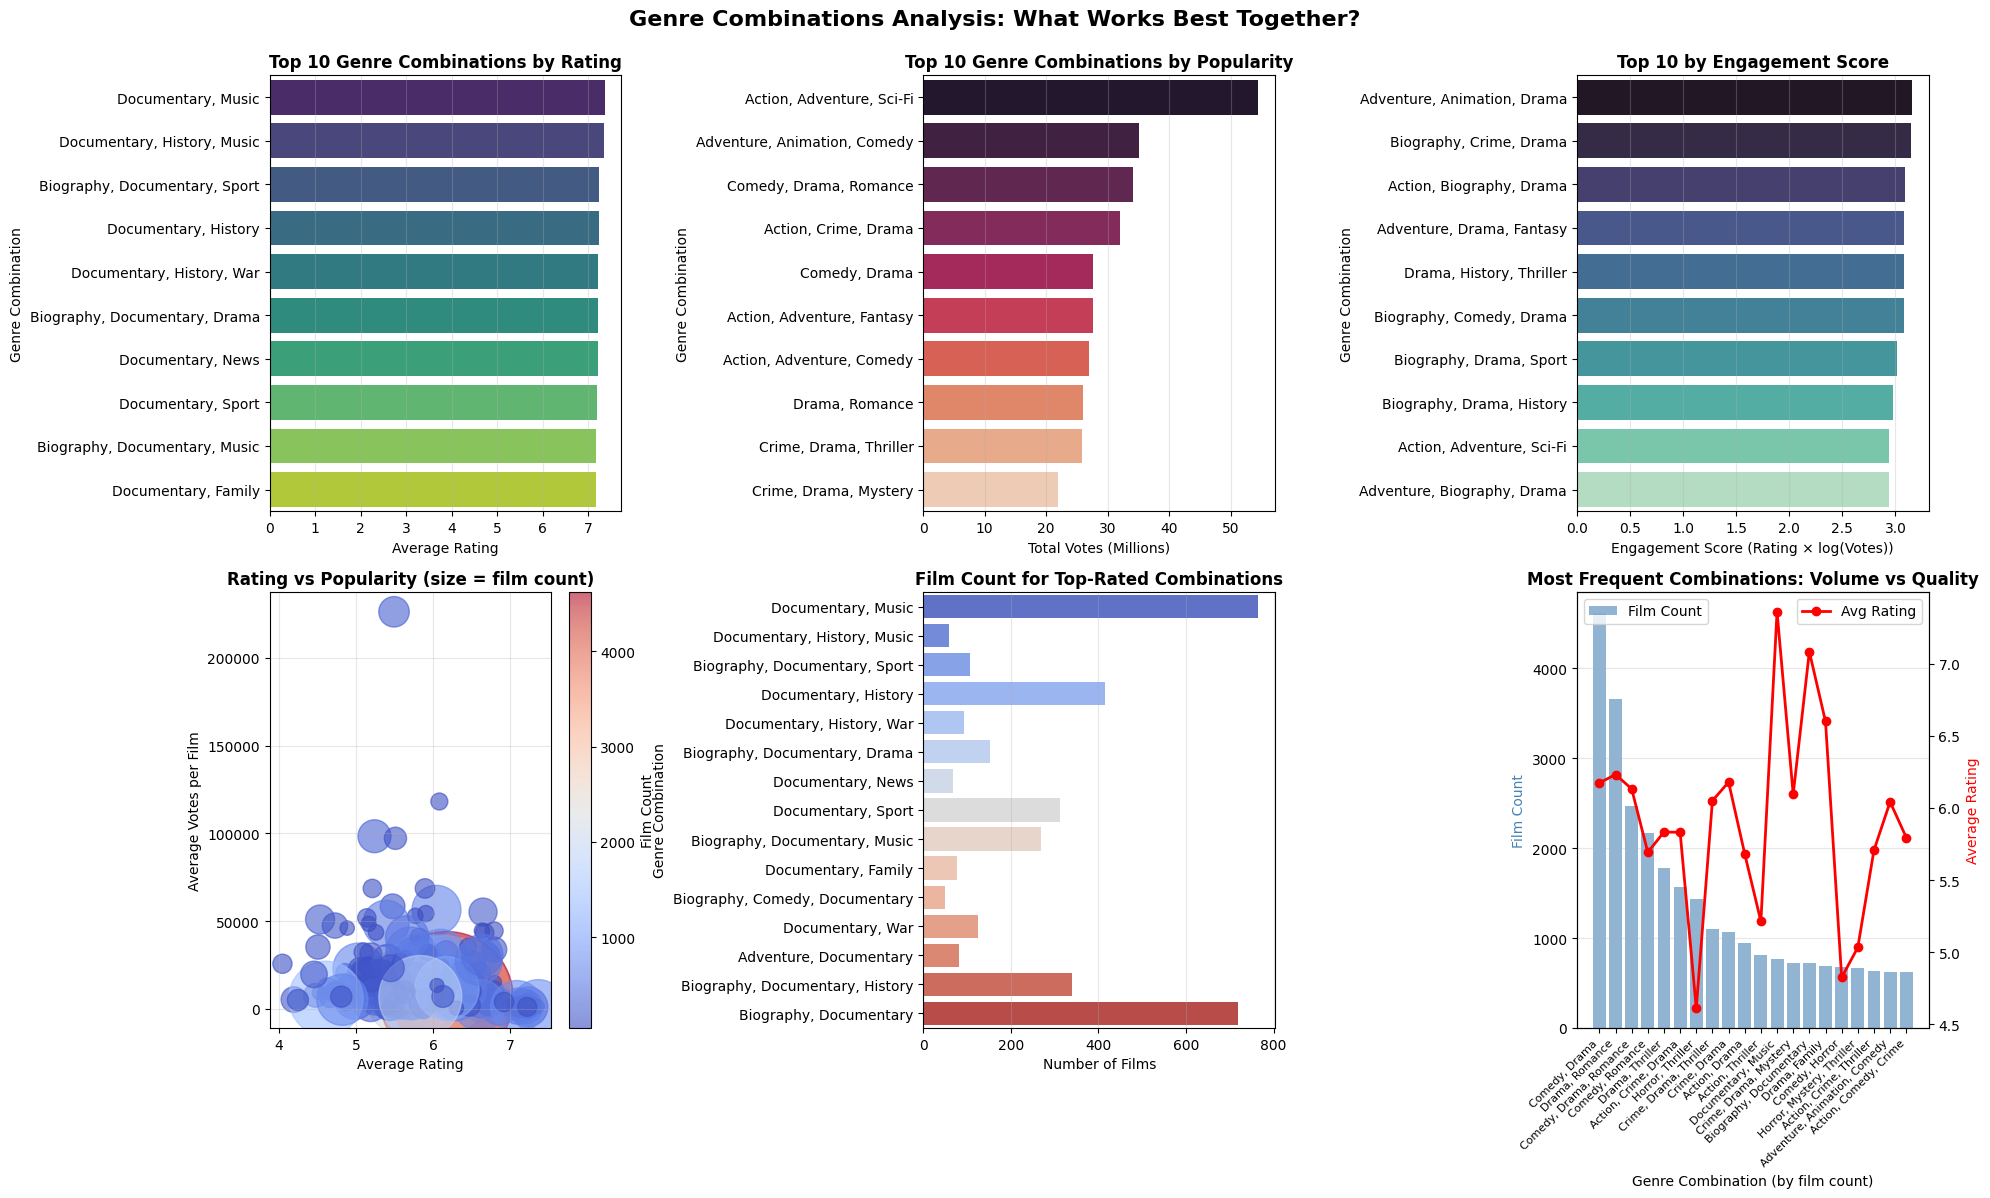


KEY INSIGHTS:


✓ Analyzed 195 unique genre combinations
✓ Top-rated combination: Documentary, Music (7.36)
✓ Most popular combination: Action, Adventure, Sci-Fi (54.5M votes)



+--------------------+----------+------------------+------------------+-----------+------------------+
|   genre_combination|film_count|        avg_rating|         avg_votes|total_votes|  engagement_score|
+--------------------+----------+------------------+------------------+-----------+------------------+
|Adventure, Animat...|        84| 6.789285688173203|44432.416666666664|    3732323|3.1554629011449857|
|Biography, Crime,...|       204| 6.645588240202735|  55116.3431372549|   11243734| 3.150864960229289|
|Action, Biography...|        89| 6.665168550577056| 43223.25842696629|    3846870|3.0897905482477643|
|Adventure, Drama,...|        75| 6.080000012715658|118119.73333333334|    8858980|3.0839742962549583|
|Drama, History, T...|        61| 6.631147556617612| 44478.57377049181|    2713193|3.0822638917708884|
|Biography, Comedy...|       159|  6.79245285118151| 33763.64150943396|    5368419| 3.075936559489136|
|Biography, Drama,...|       125|  6.71120000076294|         31136.888|  

In [17]:
result = genre_combinations_analysis(dataframes, save_path="./output")
result.show()


### Underrated Genre Combinations


Filtering by top 5 regions: DE, FR, JP, IN, ES


/app/analysis/genre_analysis.py:836: FutureWarning:                             

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


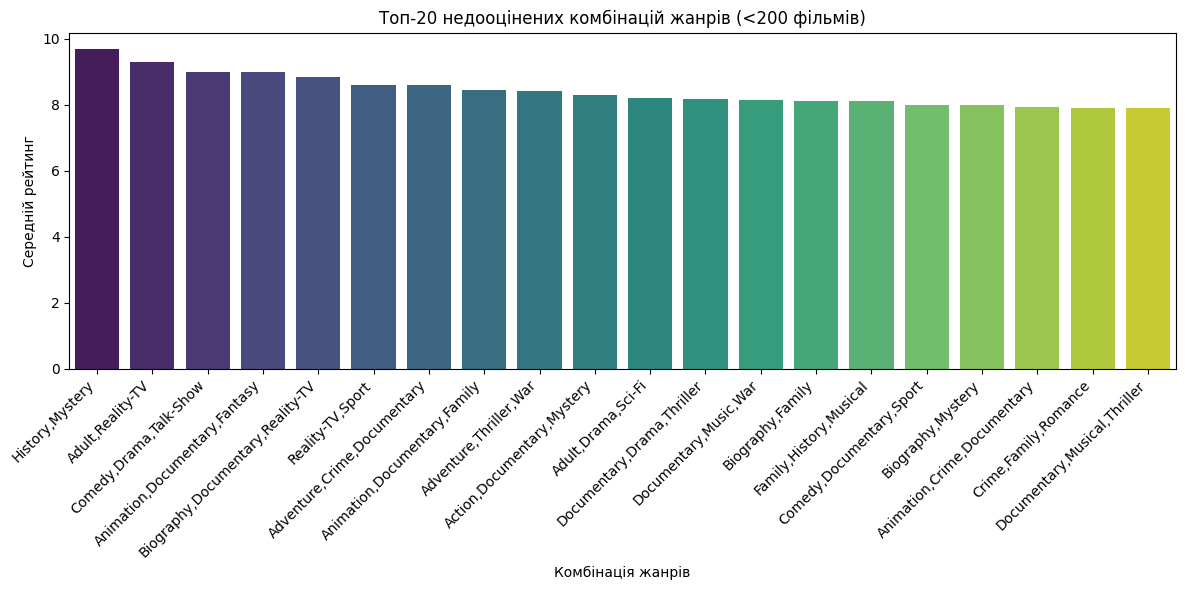

+--------------------+-----------------+----------+
|       sorted_genres|       avg_rating|film_count|
+--------------------+-----------------+----------+
|     History,Mystery|9.699999809265137|         1|
|    Adult,Reality-TV|9.300000190734863|         1|
|Comedy,Drama,Talk...|              9.0|         1|
|Animation,Documen...|              9.0|         1|
|Biography,Documen...|8.850000381469727|         2|
|    Reality-TV,Sport|8.600000381469727|         1|
|Adventure,Crime,D...|8.600000381469727|         1|
|Animation,Documen...|8.449999809265137|         2|
|Adventure,Thrille...|8.399999618530273|         1|
|Action,Documentar...|8.300000190734863|         1|
|  Adult,Drama,Sci-Fi|8.199999809265137|         1|
|Documentary,Drama...|8.175000190734863|         4|
|Documentary,Music...|8.150000095367432|         2|
|    Biography,Family|8.100000381469727|         1|
|Family,History,Mu...|8.100000381469727|         1|
|Comedy,Documentar...|              8.0|         1|
|   Biograph

In [18]:
result = underrated_genre_combos(dataframes, save_path="./output")
result.show()


---
# Director Analysis


### Directors with Increasing Ratings Trend


Filtering by top 5 regions: DE, FR, JP, IN, ES


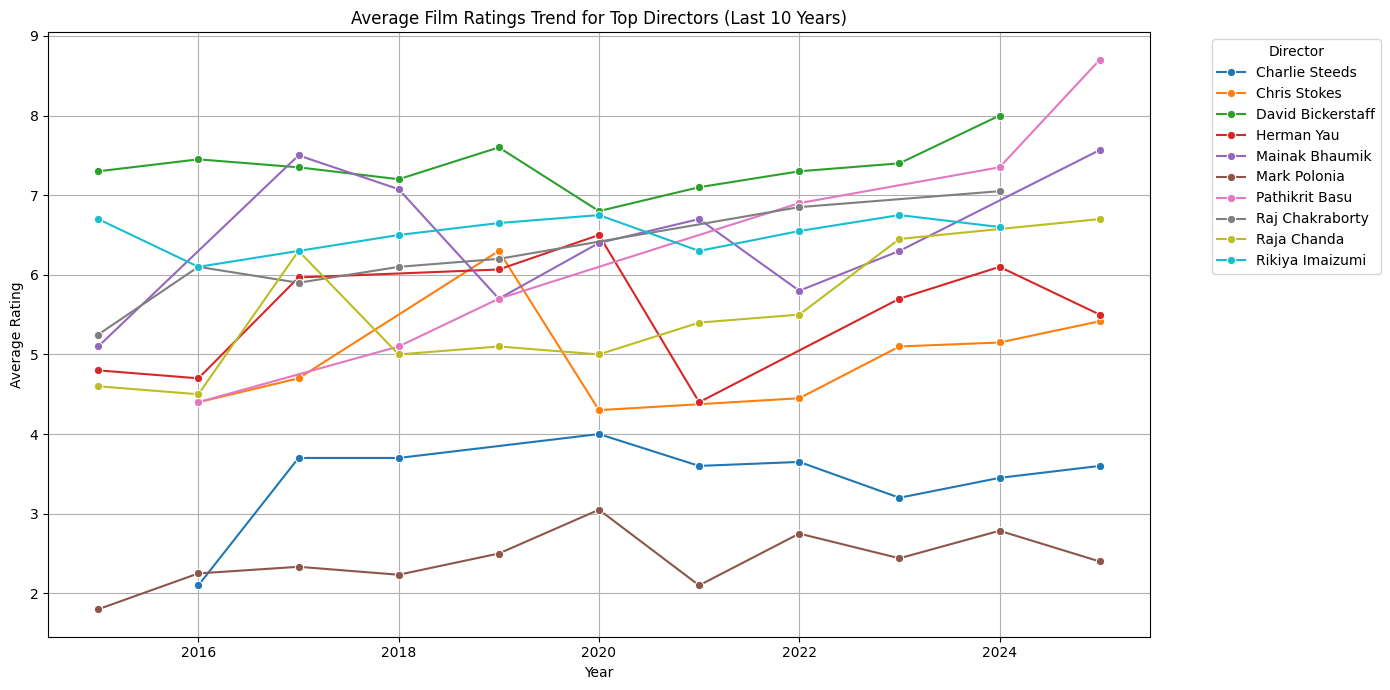

+-----------------+-----+
|      primaryName|count|
+-----------------+-----+
|     Chris Stokes|    6|
|David Bickerstaff|    6|
|     Mark Polonia|    6|
|      Raja Chanda|    6|
|  Rikiya Imaizumi|    6|
|       Anjan Dutt|    5|
|   Charlie Steeds|    5|
|   Gaizka Urresti|    5|
|       Herman Yau|    5|
|       Kaige Chen|    5|
|   Mainak Bhaumik|    5|
|   Pathikrit Basu|    5|
|  Pratim D. Gupta|    5|
|  Raj Chakraborty|    5|
|  Rizal Mantovani|    5|
|    Ryan Callaway|    5|
| Sarik Andreasyan|    5|
|    Sean McNamara|    5|
|    Takahisa Zeze|    5|
|      Yograj Bhat|    5|
+-----------------+-----+
only showing top 20 rows


In [19]:
result = directors_increasing_ratings_trend(dataframes, save_path="./output")
result.show()


### Top Directors by High Rating and Votes


Filtering by top 5 regions: DE, FR, JP, IN, ES


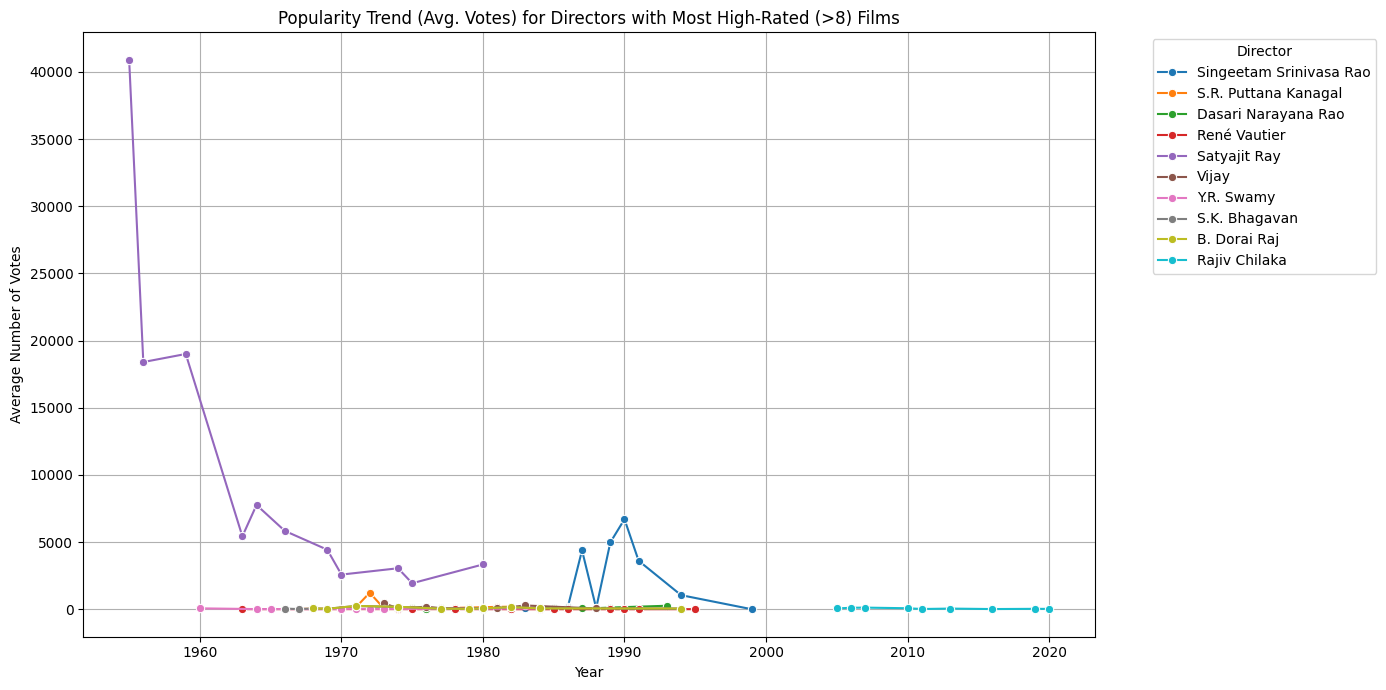

+--------------------+---------+---------+---------+
|         primaryName|startYear|num_films|avg_votes|
+--------------------+---------+---------+---------+
|            A. Kadir|     2021|        1|    473.0|
|      A. Karunakaran|     1998|        1|   5208.0|
|       A. Kasilingam|     1948|        1|      8.0|
|A. Kodandarami Reddy|     1981|        1|     60.0|
|A. Kodandarami Reddy|     1984|        1|    524.0|
|A. Kodandarami Reddy|     1989|        1|    133.0|
|        A. Mark Liiv|     2001|        1|     11.0|
|          A. Pradeep|     2022|        1|   2012.0|
|         A. Quintero|     2006|        1|    239.0|
|       A. Radhaswamy|     1994|        1|     14.0|
|           A. Salaam|     1963|        1|     10.0|
|           A. Salaam|     1966|        1|     13.0|
|         A. Sarkunam|     2011|        1|   1241.0|
|     A. Sekhar Yadav|     2021|        1|     91.0|
|A. Sunil Kumar Reddy|     2009|        1|     53.0|
|      A. Tamilselvan|     2025|        1|    

In [20]:
result = top_directors_by_high_rating_and_votes(dataframes, save_path="./output")
result.show()


### Director Career Span Analysis


Filtering by top 5 regions: DE, FR, JP, IN, ES


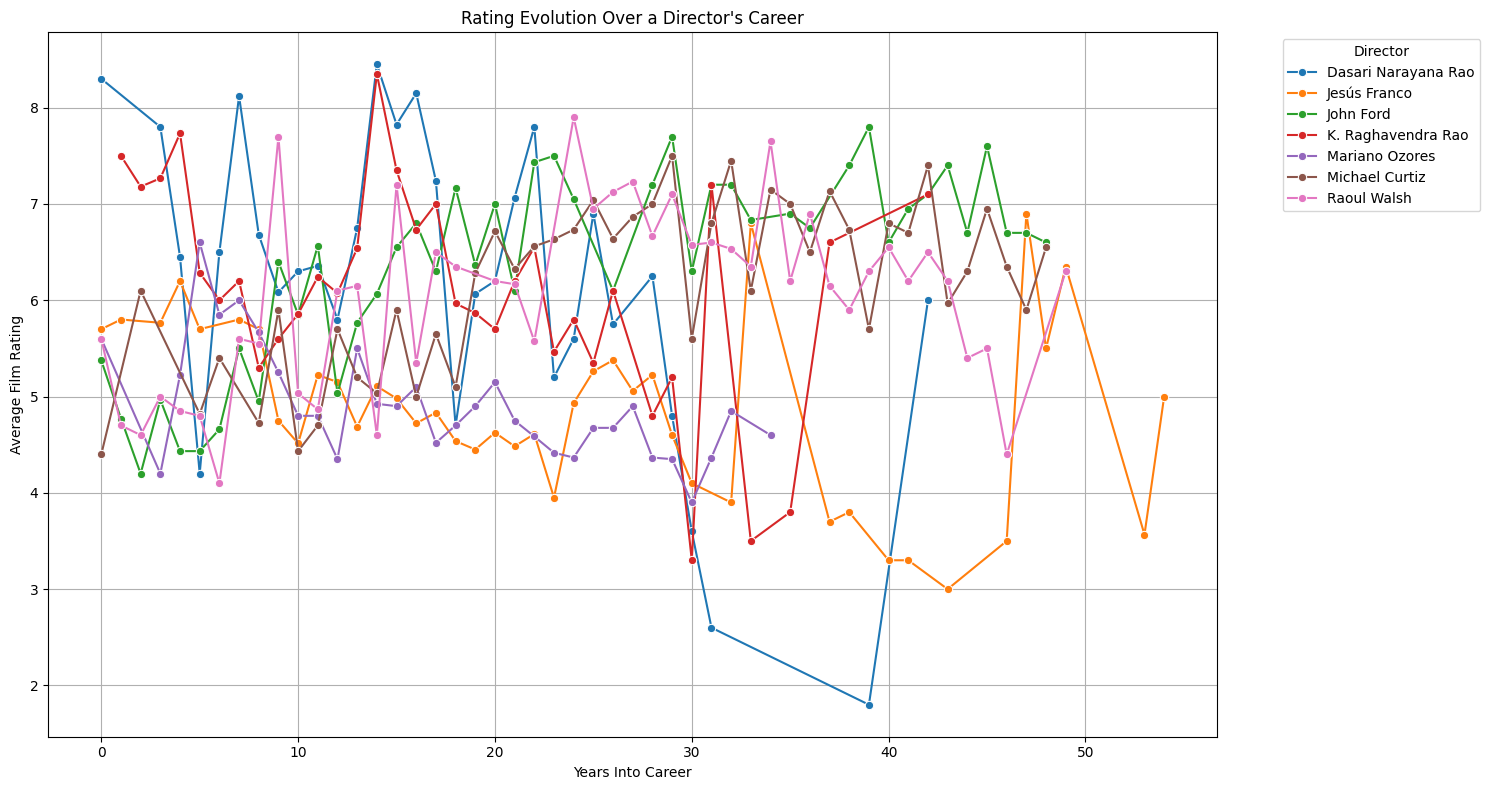

In [25]:
result = director_career_span_analysis(dataframes, save_path="./output")

---
# Collaboration Analysis


### Writer-Director Collaboration


Filtering by top 5 regions: DE, FR, JP, IN, ES


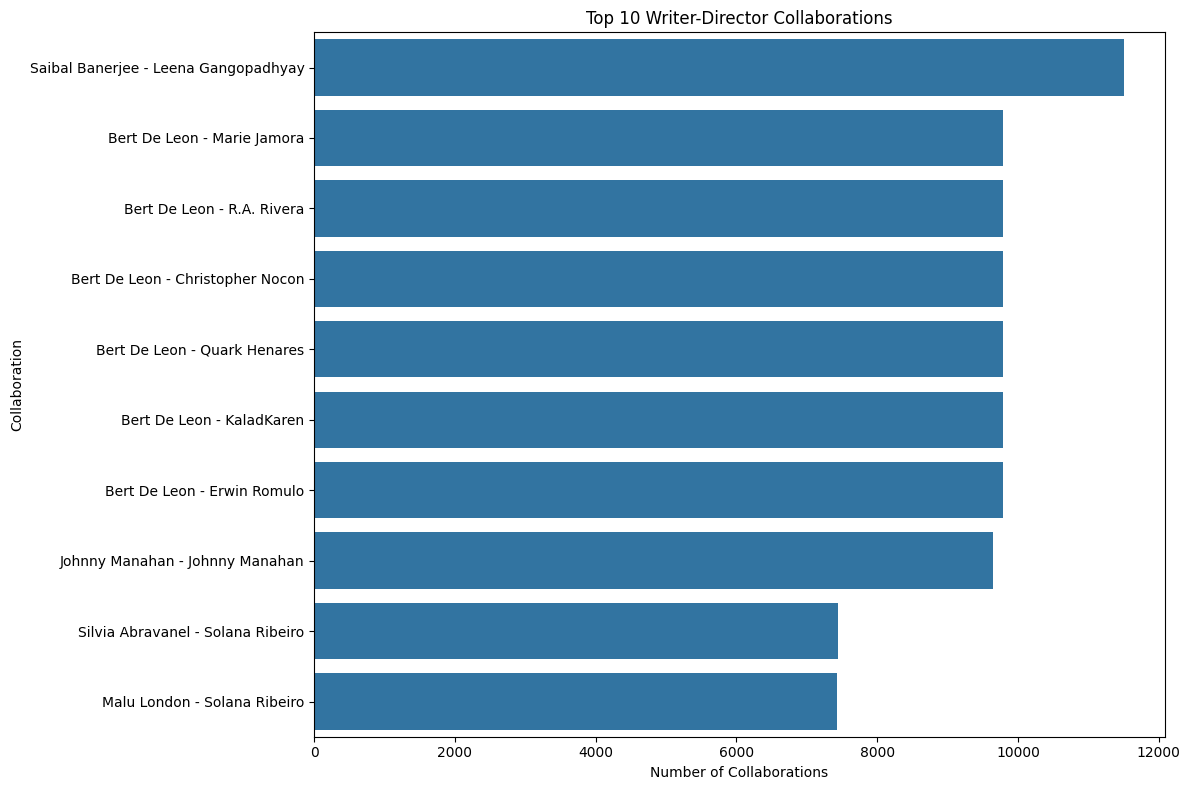

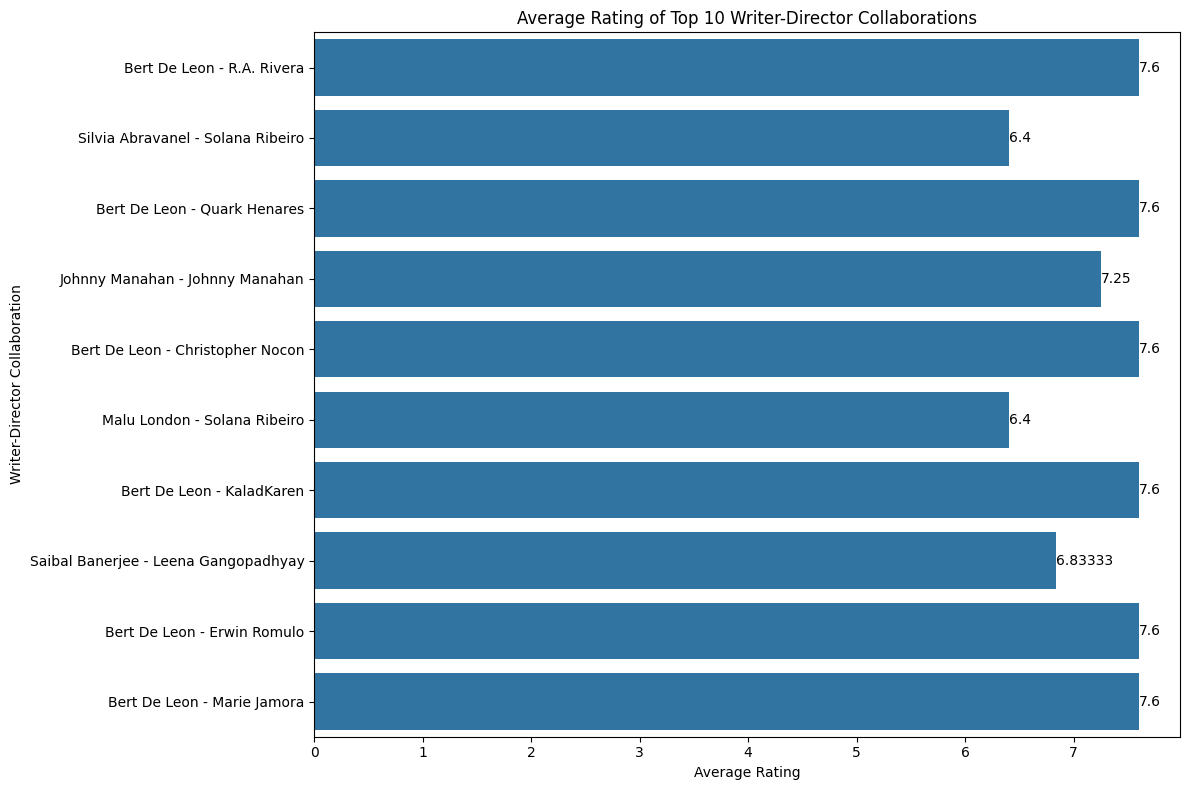

In [22]:
writer_director_collaboration(dataframes, save_path="./output")


### Actor-Director Collaboration


Filtering by top 5 regions: DE, FR, JP, IN, ES


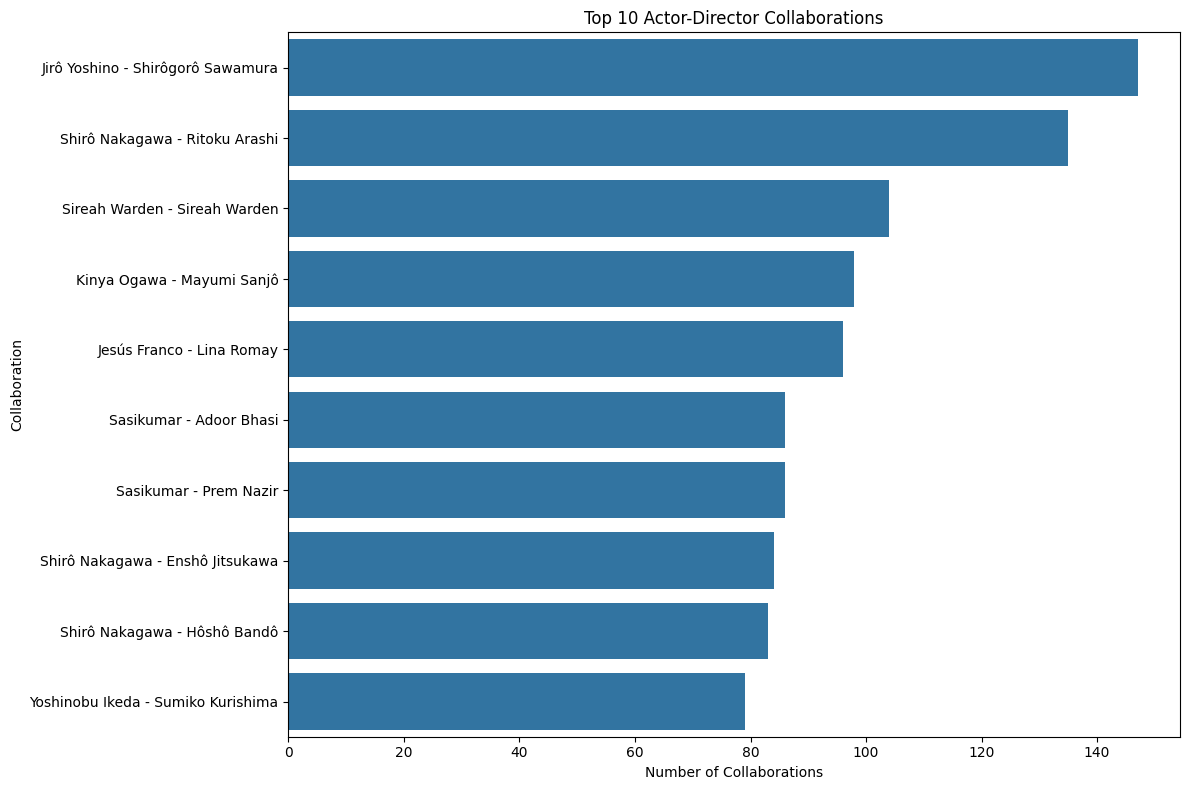

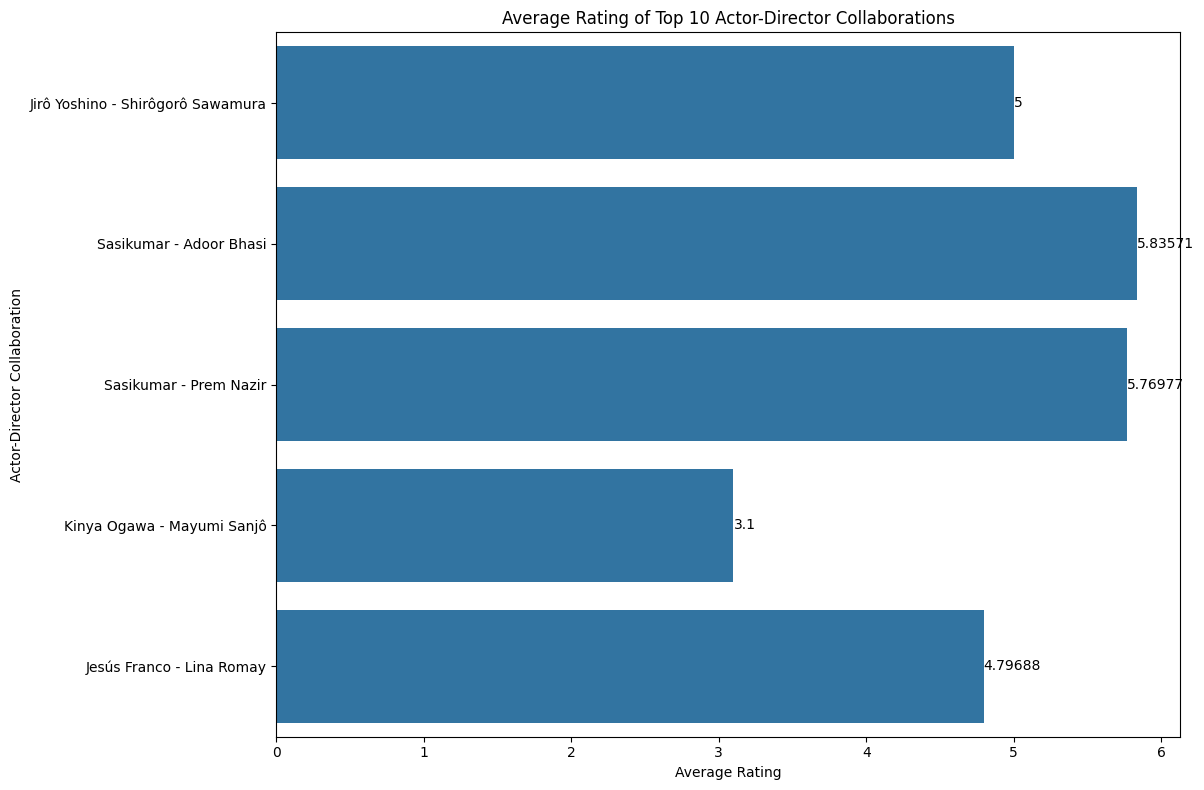

In [23]:
actor_director_collaboration(dataframes, save_path="./output")


---
# Localization Analysis


### Localization Gaps


/app/analysis/localization_analysis.py:62: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


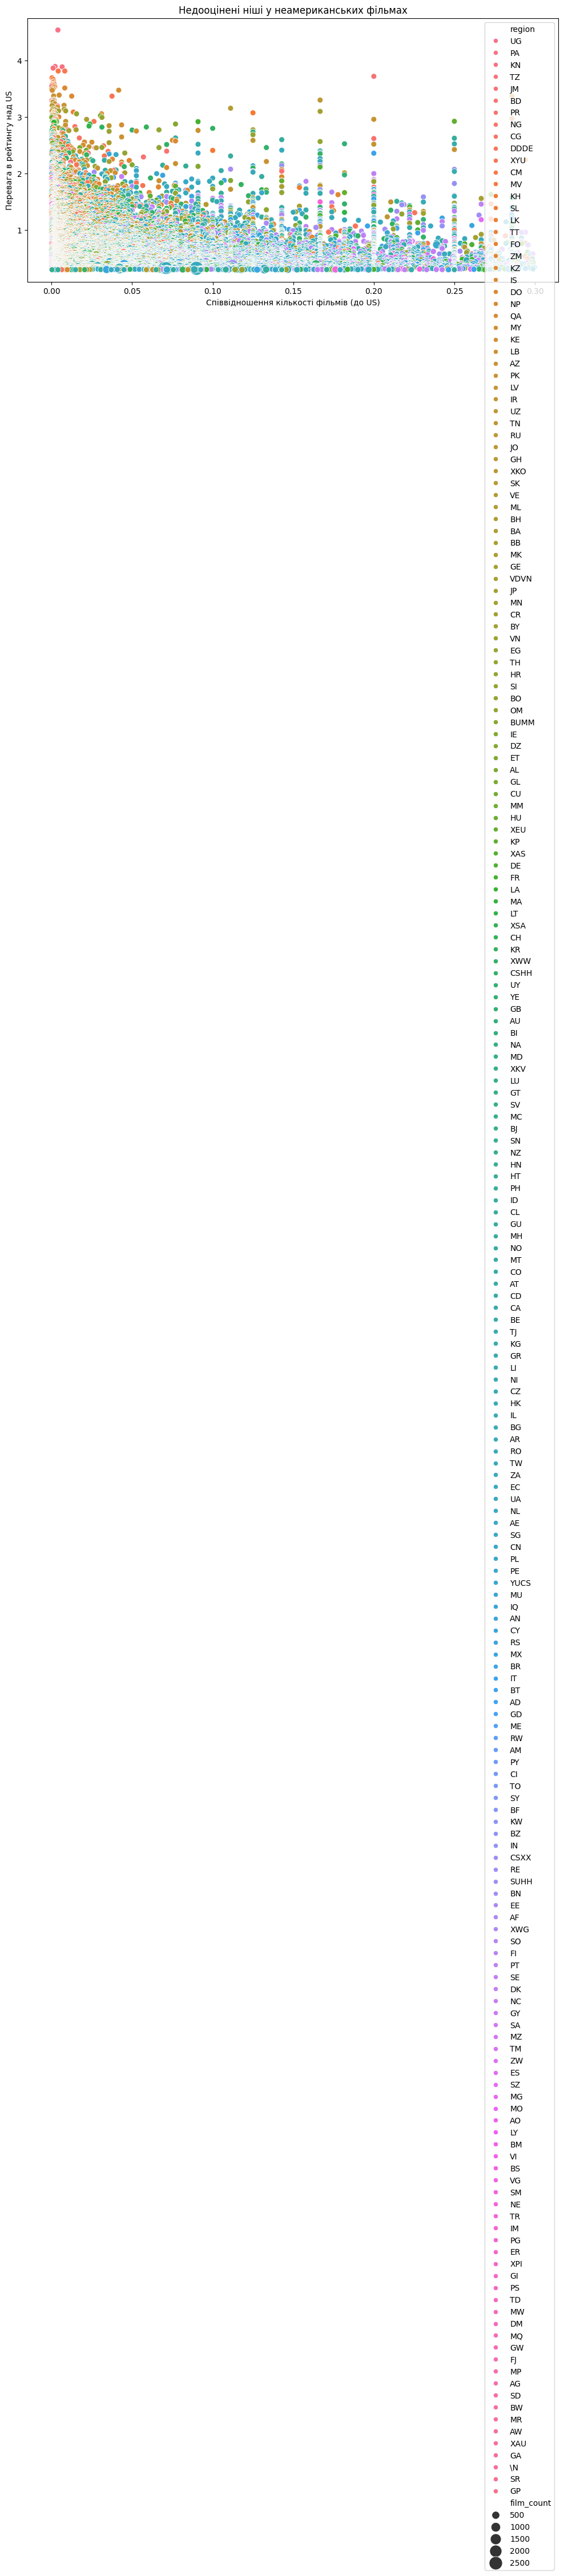

DataFrame[genres: string, region: string, avg_rating: double, film_count: bigint, us_avg_rating: double, us_film_count: bigint, rating_gap: double, production_ratio: double]

In [24]:
localization_gaps(dataframes, save_path="./output")
